# multi-omics analysis of *Yarrowia lipolytica* Reactor samples. 

This notebook analysis the omic that was obtained from Yarrowia lipolytica grown under variety of oxygen conditions in 2L bioreactors.


## Sample Information
| Sample Label | 	Media | 	Carbon source  | 	Nitrogen condition | 	comments | 
| --- | --- | --- | --- | --- |
| Ctrl | 	YNB-100gGlucose-C/N100 | 	Glucose | 	C/N 100 | pO2 set to 25% | 
| Osc | 	YNB-100gGlucose-C/N100 | Glucose | 	C/N 100 | pO2 oscillating between ~5-40%	 | 
| Low | 	YNB-100gGlucose-C/N100 | 	Glucose | 	C/N 100 | pO2 set to 5%	 |




import libraries.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import zscore
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from matplotlib.lines import Line2D

import re
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


from Bio.KEGG import REST
from Bio.KEGG.KGML import KGML_parser
import io

from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
sns.set_context("talk")
plt.rcParams['pdf.fonttype'] = 42 # when exporting as PDF, font can be edited as font

## Create sample mapping for names to conditions/reactors. 

In [2]:
# Data provided
sample_ids_prot_redox = [
    "Biostat2L_29_Oscillation_3.5", "Biostat2L_29_Oscillation_4.5", "Biostat2L_29_Oscillation_5.5",
    "Biostat2L_29_Oscillation_24", "Biostat2L_29_Oscillation_48", "Biostat2L_29_Oscillation_72",
    "Biostat2L_30_Control_3.5", "Biostat2L_30_Control_4.5", "Biostat2L_30_Control_5.5",
    "Biostat2L_30_Control_24", "Biostat2L_30_Control_48", "Biostat2L_30_Control_72",
    "Biostat2L_30_Oscillation_3.5", "Biostat2L_30_Oscillation_4.5", "Biostat2L_30_Oscillation_5.5",
    "Biostat2L_30_Oscillation_24", "Biostat2L_30_Oscillation_48", "Biostat2L_30_Oscillation_72",
    "Biostat2L_31_Control_3.5", "Biostat2L_31_Control_4.5", "Biostat2L_31_Control_5.5",
    "Biostat2L_31_Control_24", "Biostat2L_31_Control_48", "Biostat2L_31_Control_72",
    "Biostat2L_31_Oscillation_3.5", "Biostat2L_31_Oscillation_4.5", "Biostat2L_31_Oscillation_5.5",
    "Biostat2L_31_Oscillation_24", "Biostat2L_31_Oscillation_48", "Biostat2L_31_Oscillation_72",
    "Biostat2L_32_Control_3.5", "Biostat2L_32_Control_4.5", "Biostat2L_32_Control_5.5",
    "Biostat2L_32_Control_24", "Biostat2L_32_Control_48", "Biostat2L_32_Control_72",
    "Biostat2L_32_Low_3.5", "Biostat2L_32_Low_4.5", "Biostat2L_32_Low_5.5",
    "Biostat2L_32_Low_24", "Biostat2L_32_Low_48", "Biostat2L_32_Low_72",
    "Biostat2L_33_Low_3.5", "Biostat2L_33_Low_4.5", "Biostat2L_33_Low_5.5",
    "Biostat2L_33_Low_24", "Biostat2L_33_Low_48", "Biostat2L_33_Low_72",
    "Biostat2L_34_Low_3.5", "Biostat2L_34_Low_4.5", "Biostat2L_34_Low_5.5",
    "Biostat2L_34_Low_24", "Biostat2L_34_Low_48", "Biostat2L_34_Low_72",
]

sample_ids_metabolomics = [
        'PPI_Ylip_Osc_3hr_01',
        'PPI_Ylip_Osc_3hr_08',
        'PPI_Ylip_Osc_3hr_20',
        'PPI_Ylip_Osc_4hr_02',
        'PPI_Ylip_Osc_4hr_10',
        'PPI_Ylip_Osc_4hr_22',
        'PPI_Ylip_Osc_5hr_03',
        'PPI_Ylip_Osc_5hr_12',
        'PPI_Ylip_Osc_5hr_24',
        'PPI_Ylip_Osc_24hr_04',
        'PPI_Ylip_Osc_24hr_14',
        'PPI_Ylip_Osc_24hr_26',
        'PPI_Ylip_Osc_47hr_05',
        'PPI_Ylip_Osc_48hr_16',
        'PPI_Ylip_Osc_48hr_28',
        'PPI_Ylip_Osc_72hr_06',
        'PPI_Ylip_Osc_72hr_18',
        'PPI_Ylip_Osc_72hr_30',
        'PPI_Ylip_Ctrl_3hr_07',
        'PPI_Ylip_Ctrl_3hr_19',
        'PPI_Ylip_Ctrl_3hr_31',
        'PPI_Ylip_Ctrl_4hr_09',
        'PPI_Ylip_Ctrl_4hr_21',
        'PPI_Ylip_Ctrl_4hr_33',
        'PPI_Ylip_Ctrl_5hr_11',
        'PPI_Ylip_Ctrl_5hr_23',
        'PPI_Ylip_Ctrl_5hr_35',
        'PPI_Ylip_Ctrl_24hr_13',
        'PPI_Ylip_Ctrl_24hr_25',
        'PPI_Ylip_Ctrl_24hr_37',
        'PPI_Ylip_Ctrl_48hr_15',
        'PPI_Ylip_Ctrl_48hr_27',
        'PPI_Ylip_Ctrl_48hr_39',
        'PPI_Ylip_Ctrl_72hr_17',
        'PPI_Ylip_Ctrl_72hr_29',
        'PPI_Ylip_Ctrl_72hr_41',
        'PPI_Ylip_Low_3hr_32',
        'PPI_Ylip_Low_3hr_43',
        'PPI_Ylip_Low_3hr_49',
        'PPI_Ylip_Low_4hr_34',
        'PPI_Ylip_Low_4hr_44',
        'PPI_Ylip_Low_4hr_50',
        'PPI_Ylip_Low_5hr_36',
        'PPI_Ylip_Low_5hr_45',
        'PPI_Ylip_Low_5hr_51',
        'PPI_Ylip_Low_24hr_38',
        'PPI_Ylip_Low_24hr_46',
        'PPI_Ylip_Low_24hr_52',
        'PPI_Ylip_Low_48hr_40',
        'PPI_Ylip_Low_48hr_47',
        'PPI_Ylip_Low_48hr_53',
        'PPI_Ylip_Low_72hr_42',
        'PPI_Ylip_Low_72hr_48',
        'PPI_Ylip_Low_72hr_54',

]
lipid_timepoint = [
  3.5, 3.5, 3.5,
  4.5, 4.5, 4.5,
  5.5, 5.5, 5.5,
  24, 24, 24,
  48, 48, 48,
  72, 72, 72,
  3.5, 3.5, 3.5,
  4.5, 4.5, 4.5,
  5.5, 5.5, 5.5,
  24, 24, 24,
  48, 48, 48,
  72, 72, 72,
  3.5, 3.5, 3.5,
  4.5, 4.5, 4.5,
  5.5, 5.5, 5.5,
  24, 24, 24,
  48, 48, 48,
  72, 72, 72
]

sample_ids_lipidomics = [
        'PPI_Ylip_Osc_3hr_01',
        'PPI_Ylip_Osc_3hr_08',
        'PPI_Ylip_Osc_3hr_20',
        'PPI_Ylip_Osc_4hr_02',
        'PPI_Ylip_Osc_4hr_10',
        'PPI_Ylip_Osc_4hr_22',
        'PPI_Ylip_Osc_5hr_03',
        'PPI_Ylip_Osc_5hr_12',
        'PPI_Ylip_Osc_5hr_24',
        'PPI_Ylip_Osc_24hr_04',
        'PPI_Ylip_Osc_24hr_14',
        'PPI_Ylip_Osc_24hr_26',
        'PPI_Ylip_Osc_47hr_05',
        'PPI_Ylip_Osc_48hr_16',
        'PPI_Ylip_Osc_48hr_28',
        'PPI_Ylip_Osc_72hr_06',
        'PPI_Ylip_Osc_72hr_18',
        'PPI_Ylip_Osc_72hr_30',
        'PPI_Ylip_Ctrl_3hr_07',
        'PPI_Ylip_Ctrl_3hr_19',
        'PPI_Ylip_Ctrl_3hr_31',
        'PPI_Ylip_Ctrl_4hr_09',
        'PPI_Ylip_Ctrl_4hr_21',
        'PPI_Ylip_Ctrl_4hr_33',
        'PPI_Ylip_Ctrl_5hr_11',
        'PPI_Ylip_Ctrl_5hr_23',
        'PPI_Ylip_Ctrl_5hr_35',
        'PPI_Ylip_Ctrl_24hr_13',
        'PPI_Ylip_Ctrl_24hr_25',
        'PPI_Ylip_Ctrl_24hr_37',
        'PPI_Ylip_Ctrl_48hr_15',
        'PPI_Ylip_Ctrl_48hr_27',
        'PPI_Ylip_Ctrl_48hr_39',
        'PPI_Ylip_Ctrl_72hr_17',
        'PPI_Ylip_Ctrl_72hr_29',
        'PPI_Ylip_Ctrl_72hr_41',
        'PPI_Ylip_Low_3hr_32',
        'PPI_Ylip_Low_3hr_43',
        'PPI_Ylip_Low_3hr_49',
        'PPI_Ylip_Low_4hr_34',
        'PPI_Ylip_Low_4hr_44',
        'PPI_Ylip_Low_4hr_50',
        'PPI_Ylip_Low_5hr_36',
        'PPI_Ylip_Low_5hr_45',
        'PPI_Ylip_Low_5hr_51',
        'PPI_Ylip_Low_24hr_38',
        'PPI_Ylip_Low_24hr_46',
        'PPI_Ylip_Low_24hr_52',
        'PPI_Ylip_Low_48hr_40',
        'PPI_Ylip_Low_48hr_47',
        'PPI_Ylip_Low_48hr_53',
        'PPI_Ylip_Low_48hr_40',
        'PPI_Ylip_Low_48hr_47',
        'PPI_Ylip_Low_48hr_53',

]

conditions = [
    "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation",
    "Control", "Control", "Control", "Control", "Control", "Control",
    "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation",
    "Control", "Control", "Control", "Control", "Control", "Control",
    "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation",
    "Control", "Control", "Control", "Control", "Control", "Control",
    "Low", "Low", "Low", "Low", "Low", "Low",
    "Low", "Low", "Low", "Low", "Low", "Low",
    "Low", "Low", "Low", "Low", "Low", "Low"
]

timepoints = [
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
]

# Create sample_dict
sample_dict = {
    'prot_redox_ids':sample_ids_prot_redox,
    'lipid_ids':sample_ids_lipidomics,
    'lipid_timepoint': lipid_timepoint,
    'met_ids':sample_ids_metabolomics,
    "sample ID": sample_ids_prot_redox,
    "condition": conditions,
    "timepoint": timepoints,
}

lipid_condition_dict = dict(zip(sample_dict['lipid_ids'], sample_dict['condition']))
lipid_timepoint_dict = dict(zip(sample_dict['lipid_ids'], sample_dict['lipid_timepoint']))
met_condition_dict = dict(zip(sample_dict['met_ids'], sample_dict['condition']))
met_timepoint_dict = dict(zip(sample_dict['met_ids'], sample_dict['lipid_timepoint']))
prot_condition_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['condition']))
prot_timepoint_dict_2 = dict(zip(sample_dict['prot_redox_ids'], sample_dict['timepoint']))


prot_timepoint_dict = {
    "Biostat2L_29_Oscillation_3.5": "Early",
    "Biostat2L_29_Oscillation_4.5": "Early",
    "Biostat2L_29_Oscillation_5.5": "Early",
    "Biostat2L_29_Oscillation_24": "Late",
    "Biostat2L_29_Oscillation_48": "Late",
    "Biostat2L_29_Oscillation_72": "Late",
    "Biostat2L_30_Control_3.5": "Early",
    "Biostat2L_30_Control_4.5": "Early",
    "Biostat2L_30_Control_5.5": "Early",
    "Biostat2L_30_Control_24": "Late",
    "Biostat2L_30_Control_48": "Late",
    "Biostat2L_30_Control_72": "Late",
    "Biostat2L_30_Oscillation_3.5": "Early",
    "Biostat2L_30_Oscillation_4.5": "Early",
    "Biostat2L_30_Oscillation_5.5": "Early",
    "Biostat2L_30_Oscillation_24": "Late",
    "Biostat2L_30_Oscillation_48": "Late",
    "Biostat2L_30_Oscillation_72": "Late",
    "Biostat2L_31_Control_3.5": "Early",
    "Biostat2L_31_Control_4.5": "Early",
    "Biostat2L_31_Control_5.5": "Early",
    "Biostat2L_31_Control_24": "Late",
    "Biostat2L_31_Control_48": "Late",
    "Biostat2L_31_Control_72": "Late",
    "Biostat2L_31_Oscillation_3.5": "Early",
    "Biostat2L_31_Oscillation_4.5": "Early",
    "Biostat2L_31_Oscillation_5.5": "Early",
    "Biostat2L_31_Oscillation_24": "Late",
    "Biostat2L_31_Oscillation_48": "Late",
    "Biostat2L_31_Oscillation_72": "Late",
    "Biostat2L_32_Control_3.5": "Early",
    "Biostat2L_32_Control_4.5": "Early",
    "Biostat2L_32_Control_5.5": "Early",
    "Biostat2L_32_Control_24": "Late",
    "Biostat2L_32_Control_48": "Late",
    "Biostat2L_32_Control_72": "Late",
    "Biostat2L_32_Low_3.5": "Early",
    "Biostat2L_32_Low_4.5": "Early",
    "Biostat2L_32_Low_5.5": "Early",
    "Biostat2L_32_Low_24": "Late",
    "Biostat2L_32_Low_48": "Late",
    "Biostat2L_32_Low_72": "Late",
    "Biostat2L_33_Low_3.5": "Early",
    "Biostat2L_33_Low_4.5": "Early",
    "Biostat2L_33_Low_5.5": "Early",
    "Biostat2L_33_Low_24": "Late",
    "Biostat2L_33_Low_48": "Late",
    "Biostat2L_33_Low_72": "Late",
    "Biostat2L_34_Low_3.5": "Early",
    "Biostat2L_34_Low_4.5": "Early",
    "Biostat2L_34_Low_5.5": "Early",
    "Biostat2L_34_Low_24": "Late",
    "Biostat2L_34_Low_48": "Late",
    "Biostat2L_34_Low_72": "Late",
}



## Definitions.

In [3]:
def plot_pca(pca_df, explained_variance, hue='Condition', time='Timepoint', title=None):
    # Font style
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']

    # Force condition order and assign colors manually
    condition_order = ['Control', 'Low', 'Oscillation']
    color_palette = {
        'Control': '#9467bd',     # purple
        'Low': '#2ca02c',         # red
        'Oscillation': '#6495ED'  # blue
    }
    pca_df[hue] = pd.Categorical(pca_df[hue], categories=condition_order, ordered=True)

    # Timepoint to marker shape
    marker_styles = {
        24.0: 'v',   # triangle down
        48.0: 's',   # square
        72.0: 'D'    # diamond
    }
    default_marker = 'o'
    pca_df['Marker'] = pca_df[time].map(marker_styles).fillna(default_marker)

    # Create the plot
    plt.figure(figsize=(8, 8))
    ax = sns.scatterplot(
        x='PC1', y='PC2',
        hue=hue,
        hue_order=condition_order,
        style='Marker',
        markers={'o': 'o', 'v': 'v', 's': 's', 'D': 'D'},
        palette=color_palette,
        data=pca_df,
        s=150
    )

    # Label axes
    plt.xlabel(f'PC1 ({explained_variance[0]*100:.2f}% variance)', fontsize=24)
    plt.ylabel(f'PC2 ({explained_variance[1]*100:.2f}% variance)', fontsize=24)

    # Custom shape legend
    shape_legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='< 24 h', markersize=10, markerfacecolor='black'),

        Line2D([0], [0], marker='v', color='w', label='24 h', markersize=10, markerfacecolor='black'),
        Line2D([0], [0], marker='s', color='w', label='48 h', markersize=10, markerfacecolor='black'),
        Line2D([0], [0], marker='D', color='w', label='72 h', markersize=10, markerfacecolor='black'),
    ]

    # Manually control legends to prevent cutoff & missing entries
    handles, labels = ax.get_legend_handles_labels()
    condition_handles = [h for h, l in zip(handles, labels) if l in condition_order]
    condition_labels = condition_order  # preserve order

    # Add condition legend
    first_legend = plt.legend(
        condition_handles, condition_labels,
        title=hue, bbox_to_anchor=(0.95, .75), loc='upper left',
        frameon=False, fontsize=16, title_fontsize=16
    )
    ax.add_artist(first_legend)

    # Add timepoint shape legend
    plt.legend(
        title='Time (h)', 
        handles=shape_legend_elements,
        bbox_to_anchor=(1.0, 0.50), loc='upper left',
        frameon=False, fontsize=16, title_fontsize=16
    )

    # Clean up axes and ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='both', which='major', width=0.5, labelsize=20)
    plt.xticks(size=16)
    plt.yticks(size=16)

    # Prevent legends from getting cut off
    plt.tight_layout()

    # Save if filename provided
    if title:
        # plt.savefig(title, dpi=600, bbox_inches='tight', facecolor='white')
        plt.savefig(title+".png", dpi=600, bbox_inches="tight", facecolor="white")
        # or
        plt.savefig(title+".tiff", dpi=600, bbox_inches="tight")
        plt.savefig(title+".pdf", bbox_inches="tight" )
        plt.savefig(title+".svg", bbox_inches="tight")
    plt.show()


def global_stats_calc_prot(df, condition_series, id_col='Site'):
    """
    df: rows = proteins/sites, columns = samples + (optionally) id_col
    condition_series: index = sample names matching df sample columns
    id_col: column in df identifying the protein/site (default 'Site')
    """

    # Work on a copy and ensure we have an identifier column to merge on
    df_out = df.copy()

    
    # Avoid: id_col is both index level and column
    if df_out.index.name == id_col and id_col in df_out.columns:
        df_out = df_out.reset_index(drop=True)
    elif df_out.index.name == id_col and id_col not in df_out.columns:
        df_out = df_out.reset_index()    
    # if id_col not in df_out.columns:
    #     # if your df uses the index as the id, promote it to a column
    #     df_out[id_col] = df_out.index

    # Use id as index for analysis
    data = df_out.set_index(id_col)

    # Drop any NaN-valued entries (e.g. accidental 'Protein'/'ProteinID' rows)
    condition_series = condition_series.dropna()

    sample_cols = [c for c in data.columns if c in condition_series.index]
    # Keep only sample columns that exist in condition_series
    sample_cols = [c for c in data.columns if c in condition_series.index]
    t_data = data[sample_cols].T  # rows=samples, cols=proteins/sites

    unique_conditions = pd.unique(condition_series.loc[sample_cols])

    anova_results = {}
    for prot in t_data.columns:
        group_data = []
        for cond in unique_conditions:
            idx = condition_series[(condition_series == cond)].index
            idx = [i for i in idx if i in t_data.index]  # align to available samples
            vals = t_data.loc[idx, prot].dropna().values
            group_data.append(vals)

        # skip if any group has no data
        if any(len(g) == 0 for g in group_data):
            continue

        try:
            _, p = f_oneway(*group_data)
            anova_results[prot] = p
        except Exception:
            continue

    # Build results df and ALWAYS create padj column
    anova_df = pd.DataFrame.from_dict(anova_results, orient='index', columns=['ANOVA_p'])
    anova_df['ANOVA_padj'] = np.nan
    if len(anova_df) > 0:
        anova_df['ANOVA_padj'] = multipletests(anova_df['ANOVA_p'].values, method='fdr_bh')[1]

    # Merge back (even if anova_df is empty, columns will exist in output as NaN)
    anova_df = anova_df.reset_index().rename(columns={'index': id_col})
    merged_df = df_out.merge(anova_df, on=id_col, how='left')

    # Ensure columns exist even if merge produced none (paranoia)
    for col in ['ANOVA_p', 'ANOVA_padj']:
        if col not in merged_df.columns:
            merged_df[col] = np.nan

    return merged_df

def sort_by_significance(df,key_stat='ANOVA_padj'):
    if key_stat not in df.columns:
        raise KeyError("'Key_stat column is missing. Ensure ANOVA has been performed.")
    
    # Sort the DataFrame based on 'ANOVA_p' for significance
    # If you want to use 'ANOVA_padj', you can replace 'ANOVA_p' with 'ANOVA_padj'
    sorted_df = df.sort_values(by=key_stat).copy()

    # Select the top 100 most significant
    top_100_df = sorted_df.head(100)

    return top_100_df

def pca_preprocess(df):
    # Standardize the features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df)

    # Perform PCA
    # pca = make_pipeline(StandardScaler(), PCA())

    # pca = PCA()#n_components=2)  # Reduce to 2 components for visualization
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    pca_result = pca.fit_transform(df)

    # Capture the explained variance for each component
    explained_variance = pca.explained_variance_ratio_

    # Create a new DataFrame with PCA results
    # pca_df = pd.DataFrame(
    #     pca_result,
    #     columns=[f"PC{i+1}" for i in range(pca_result.shape[1])]
    # )
    pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
    return pca_df, explained_variance


def get_dynamic_limits(df):
    # Compute the overall minimum and maximum values from the dataset
    x_min = df.min()[0]-1
    x_max = df.max()[0]+1
    
    y_min = 0
    y_max = dataset.max()[2]+1

    return x_min,x_max,y_min,y_max


def volcano_plot(dataset,title=None):
    fig,ax = plt.subplots(1,1,figsize=(7,7))

    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    
    x_min,x_max, y_min,y_max = get_dynamic_limits(dataset)

    x_limits = (x_min,x_max)
    y_limits = (0,y_max)
    
    y_cutoff = -np.log10(0.05)
    x_cutoff = 0.37851162325
    sns.scatterplot(data = dataset, 
                    x = 'log2FC', 
                    y = '-logP_adj', 
                    hue='class', 
                    s = 25, alpha = 0.5, palette=['#0571B0','#BABABA','#CA0020'], ax=ax)
    legend_handles, _= ax.get_legend_handles_labels()
    
    legend = ax.legend(legend_handles, ['down-regulated','not significant','up-regulated'], 
              bbox_to_anchor=(1,1), 
              title='')
    
    legend.get_frame().set_edgecolor('none')  # Disable the border

    ax.plot(x_limits,[y_cutoff,y_cutoff],'k--')
    ax.plot([x_cutoff,x_cutoff],y_limits,'k--')
    ax.plot([-x_cutoff,-x_cutoff],y_limits,'k--')
    ax.set_ylabel(r'-Log$_2$(P$_{adj}$)', fontsize=24)
    ax.set_xlabel(r'Log$_2$(FC)', fontsize=24)
    if title:
        fig.savefig(title+'.png')

def log2FC_function(df1,df2):
    # substrates 1 dataframe from the second. 
    mean1 = df1.mean(axis=1)
    mean2 = df2.mean(axis=1)
    return (mean1-mean2)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd

def annotate_top_genes(ax, dataset, num_top=5):
    """
    Annotates the top up-regulated and down-regulated genes on the volcano plot with dynamic text positioning.
    """
    # Sort dataset by log2FC and find top up-regulated and down-regulated genes
    top_up = dataset.nlargest(num_top, 'log2FC')
    top_down = dataset.nsmallest(num_top, 'log2FC')

    # Combine top genes using pd.concat (instead of deprecated append)
    top_genes = pd.concat([top_up, top_down])
    
    for protein_id, row in top_genes.iterrows():
        # Determine text position based on log2FC (right for positive, left for negative)
        if row['log2FC'] > 0:
            xytext = (row['log2FC'] + 0.5, row['-logP_adj'] + 0.5)  # Right-hand side for positive values
        else:
            xytext = (row['log2FC'] - 0.5, row['-logP_adj'] + 0.5)  # Left-hand side for negative values
        
        ax.annotate(
            protein_id, # Annotate with proteinID, which is the index
            xy=(row['log2FC'], row['-logP_adj']), # Point where annotation starts
            xytext=xytext, # Adjust text placement dynamically
            fontsize=10,
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5), # Arrow pointing to the data point
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white") # Label background
        )


def volcano_plot_annotate(dataset, title=None):
    """
    Function to plot the volcano plot and annotate the top 5 up-regulated and down-regulated genes with arrows.
    """
    # Extract dynamic plot limits
    x_min, x_max, y_min, y_max = get_dynamic_limits(dataset)
    x_limits = (x_min, x_max)
    y_limits = (0, y_max)

    # Initialize plot
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']

    # Add scatter plot
    sns.scatterplot(data=dataset, 
                    x='log2FC', 
                    y='-logP_adj', 
                    hue='class', 
                    s=25, alpha=0.5, palette=['#0571B0','#BABABA','#CA0020'], ax=ax)
    
    # Add legend
    legend_handles, _ = ax.get_legend_handles_labels()
    legend = ax.legend(legend_handles, ['down-regulated', 'not significant', 'up-regulated'], 
                       bbox_to_anchor=(1, 1), title='')
    legend.get_frame().set_edgecolor('none')  # Disable legend border

    # Draw threshold cutoff lines
    y_cutoff = -np.log10(0.05)
    x_cutoff = 0.37851162325
    ax.plot(x_limits, [y_cutoff, y_cutoff], 'k--')
    ax.plot([x_cutoff, x_cutoff], y_limits, 'k--')
    ax.plot([-x_cutoff, -x_cutoff], y_limits, 'k--')

    # Label axes
    ax.set_ylabel(r'-Log$_2$(P$_{adj}$)', fontsize=24)
    ax.set_xlabel(r'Log$_2$(FC)', fontsize=24)

    # Annotate the top genes
    annotate_top_genes(ax, dataset)

    # Save the plot if a title is provided
    if title:
        fig.savefig(f"{title}.png")

    return fig, ax


# Read in Annotations.



Annotations downloaded for FKP355 strain from JGI, June 2025.


https://mycocosm.jgi.doe.gov/pages/search-for-genes.jsf?organism=Yarlip1

### grab KEGG info.

In [4]:
KEGGannotate = pd.read_table('../Annotations/Filtered Models ("best")/Functional Annotations/EC annotations and KEGG pathway mappings/YarliW29_1_GeneCatalog_proteins_20190319_KEGG.tab')
# annotate.index = annotate.index.map(str)
KEGGannotate.head()
# Kegg_pathwayDict = dict(zip(annotate.index,annotate.pathway))

,#proteinId,ecNum,definition,catalyticActivity,cofactors,associatedDiseases,pathway,pathway_class,pathway_type
0,5,4.2.1.24,Porphobilinogen synthase.,2 5-aminolevulinate = porphobilinogen + 2 H(2)O.,Zinc.,Susceptibility to lead poisoning; MIM:125270. ...,Porphyrin and chlorophyll metabolism,Metabolism of Cofactors and Vitamins,METABOLIC
1,11,6.1.1.5,Isoleucine--tRNA ligase.,ATP + L-isoleucine + tRNA(Ile) = AMP + diphosp...,\N,\N,"Valine, leucine and isoleucine biosynthesis",Amino Acid Metabolism,METABOLIC
2,11,6.1.1.5,Isoleucine--tRNA ligase.,ATP + L-isoleucine + tRNA(Ile) = AMP + diphosp...,\N,\N,Aminoacyl-tRNA biosynthesis,TRANSLATION,REGULATORY
3,32,3.1.4.46,Glycerophosphodiester phosphodiesterase.,A glycerophosphodiester + H(2)O = an alcohol +...,\N,\N,Phospholipid degradation,Metabolism of Complex Lipids,METABOLIC
4,32,3.1.4.46,Glycerophosphodiester phosphodiesterase.,A glycerophosphodiester + H(2)O = an alcohol +...,\N,\N,Glycerolipid metabolism,Metabolism of Complex Lipids,METABOLIC


In [5]:
KEGGannotate.shape

(2516, 9)

In [6]:
# Group by 'proteinId' and aggregate columns into lists for simpler downstream processing. 
KEGGannotate = KEGGannotate.groupby('#proteinId').agg({
    'definition': list,
    'catalyticActivity': list,
    'pathway': list,
    'pathway_class': list,
    'pathway_type': list,
    'ecNum': list,
    'cofactors': list,
}).reset_index()

### grab GO info.

In [7]:
GOannotate  = pd.read_table('../Annotations/Filtered Models ("best")/Functional Annotations/GO/YarliW29_1_GeneCatalog_proteins_20190319_GO.tab')

GOannotate.head()

,#proteinId,gotermId,goName,gotermType,goAcc
0,5,3028,porphobilinogen synthase activity,molecular_function,GO:0004655
1,11,162,nucleotide binding,molecular_function,GO:0000166
2,11,3172,aminoacyl-tRNA ligase activity,molecular_function,GO:0004812
3,11,3736,ATP binding,molecular_function,GO:0005524
4,11,3930,cytoplasm,cellular_component,GO:0005737


In [8]:
# Group by 'proteinId' and aggregate columns into lists for simpler downstream processing. 
GOannotate = GOannotate.groupby('#proteinId').agg({
    'gotermId': list,
    'gotermType': list,
    'goName': list,
    'goAcc': list,
}).reset_index()

## Merge annotations.

In [9]:
merged_annotations = pd.merge(KEGGannotate, GOannotate, on='#proteinId', how='outer')

# Merge the result with df3
# merged_annotations = pd.merge(merged_annotations, KEGGannotate, on='proteinId', how='outer')

In [10]:
merged_annotations.head()

,#proteinId,definition,catalyticActivity,pathway,pathway_class,pathway_type,ecNum,cofactors,gotermId,gotermType,goName,goAcc
0,5,[Porphobilinogen synthase.],[2 5-aminolevulinate = porphobilinogen + 2 H(2...,[Porphyrin and chlorophyll metabolism],[Metabolism of Cofactors and Vitamins],[METABOLIC],[4.2.1.24],[Zinc.],[3028],[molecular_function],[porphobilinogen synthase activity],[GO:0004655]
1,11,"[Isoleucine--tRNA ligase., Isoleucine--tRNA li...",[ATP + L-isoleucine + tRNA(Ile) = AMP + diphos...,"[Valine, leucine and isoleucine biosynthesis, ...","[Amino Acid Metabolism, TRANSLATION]","[METABOLIC, REGULATORY]","[6.1.1.5, 6.1.1.5]","[\N, \N]","[162, 3172, 3736, 3930, 4556, 4561, 3182, 4571]","[molecular_function, molecular_function, molec...","[nucleotide binding, aminoacyl-tRNA ligase act...","[GO:0000166, GO:0004812, GO:0005524, GO:000573..."
2,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3737],[molecular_function],[GTP binding],[GO:0005525]
3,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[4604, 5817]","[biological_process, molecular_function]","[protein amino acid dephosphorylation, protein...","[GO:0006470, GO:0008138]"
4,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[3737, 2378, 24058]","[molecular_function, molecular_function, molec...","[GTP binding, GTPase activity, hydrolase activ...","[GO:0005525, GO:0003924, GO:0050800]"


In [11]:
# merged_annotations.to_csv('../Annotations/GO_KEGG_EC_annotations.csv')

## grab KOG info. 

In [12]:
kog_annotations = pd.read_table('../Annotations/Filtered Models ("best")/Functional Annotations/YarliW29_1_GeneCatalog_proteins_20190319_KOG.tab')
kog_annotations.rename(columns={'proteinId': '#proteinId'}, inplace=True)

In [13]:
kog_annotations.head()

,#transcriptId,#proteinId,kogid,kogdefline,kogClass,kogGroup
0,6541,5563,KOG0001,Ubiquitin and ubiquitin-like proteins,"Posttranslational modification, protein turnov...",CELLULAR PROCESSES AND SIGNALING
1,6541,5563,KOG0001,Ubiquitin and ubiquitin-like proteins,General function prediction only,POORLY CHARACTERIZED
2,7831,6853,KOG0004,Ubiquitin/40S ribosomal protein S27a fusion,"Translation, ribosomal structure and biogenesis",INFORMATION STORAGE AND PROCESSING
3,8270,7292,KOG0005,Ubiquitin-like protein,"Cell cycle control, cell division, chromosome ...",METABOLISM
4,8270,7292,KOG0005,Ubiquitin-like protein,"Posttranslational modification, protein turnov...",CELLULAR PROCESSES AND SIGNALING


In [14]:
# Group by 'proteinId' and aggregate columns into lists for simpler downstream processing. 
kog_annotations = kog_annotations.groupby('#proteinId').agg({
    'kogid': list,
    'kogdefline': list,
    'kogClass': list,
    'kogGroup': list,
}).reset_index()

## Merge KOG with KEGG / GO annotations.

In [15]:
merged_annotations = pd.merge(kog_annotations, merged_annotations, on='#proteinId', how='outer')

# Merge the result with df3
# merged_annotations = pd.merge(merged_annotations, KEGGannotate, on='proteinId', how='outer')

In [16]:
merged_annotations.head()

,#proteinId,kogid,kogdefline,kogClass,kogGroup,definition,catalyticActivity,pathway,pathway_class,pathway_type,ecNum,cofactors,gotermId,gotermType,goName,goAcc
0,4,[KOG2262],[Sexual differentiation process protein ISP4],[Signal transduction mechanisms ],[CELLULAR PROCESSES AND SIGNALING],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5,[KOG0101],"[Molecular chaperones HSP70/HSC70, HSP70 super...","[Posttranslational modification, protein turno...",[CELLULAR PROCESSES AND SIGNALING],[Porphobilinogen synthase.],[2 5-aminolevulinate = porphobilinogen + 2 H(2...,[Porphyrin and chlorophyll metabolism],[Metabolism of Cofactors and Vitamins],[METABOLIC],[4.2.1.24],[Zinc.],[3028],[molecular_function],[porphobilinogen synthase activity],[GO:0004655]
2,11,[KOG0434],[Isoleucyl-tRNA synthetase],"[Translation, ribosomal structure and biogenes...",[INFORMATION STORAGE AND PROCESSING],"[Isoleucine--tRNA ligase., Isoleucine--tRNA li...",[ATP + L-isoleucine + tRNA(Ile) = AMP + diphos...,"[Valine, leucine and isoleucine biosynthesis, ...","[Amino Acid Metabolism, TRANSLATION]","[METABOLIC, REGULATORY]","[6.1.1.5, 6.1.1.5]","[\N, \N]","[162, 3172, 3736, 3930, 4556, 4561, 3182, 4571]","[molecular_function, molecular_function, molec...","[nucleotide binding, aminoacyl-tRNA ligase act...","[GO:0000166, GO:0004812, GO:0005524, GO:000573..."
3,12,[KOG1487],[GTP-binding protein DRG1 (ODN superfamily)],[Signal transduction mechanisms ],[CELLULAR PROCESSES AND SIGNALING],NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3737],[molecular_function],[GTP binding],[GO:0005525]
4,13,[KOG1716],[Dual specificity phosphatase],[Defense mechanisms ],[CELLULAR PROCESSES AND SIGNALING],NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[4604, 5817]","[biological_process, molecular_function]","[protein amino acid dephosphorylation, protein...","[GO:0006470, GO:0008138]"


## save annotation file.

In [17]:
# merged_annotations.to_csv('../Annotations/KOG_GO_KEGG_EC_annotations.csv')

In [18]:
annot_plus_kog = merged_annotations.copy()

# Read in protein and PTM data. 

In [19]:
# proteomics_data = pd.read_csv('../Data/PPI_yarrowia_REDOX_Global/result/PTM/PPI_yarrowia_protein_abundance.csv')
# with annotations
# proteomics_data = pd.read_csv('../Data/Proteomic_PTMs/redox_global/PPI_yarrowia_protein_abundance_wAnnotations.csv')

phospho_data = pd.read_csv('../Data/Proteomic_PTMs/redox_global/PPI_yarrowia_all_ptms.csv')
# phospho_data = pd.read_csv('../Data/PPI_yarrowia_REDOX_Global/Phospho/PPI_yarrowia/result/PTM/PPI_yarrowia_all_ptms.csv')
# phospho_data = phospho_data[phospho_data['Type']=='Ph']

phopho = phospho_data[sample_ids_prot_redox]

In [20]:
phospho_data.head()

,Peptide,Site,UniProt,Protein,Residue,id,Total missingness,Oscillation_24 missingness,Oscillation_3.5 missingness,Oscillation_4.5 missingness,...,Oscillation_24/Oscillation_3.5_adj-p,Oscillation_48/Oscillation_3.5,Oscillation_48/Oscillation_3.5_pval,Oscillation_48/Oscillation_3.5_adj-p,Oscillation_72/Oscillation_3.5,Oscillation_72/Oscillation_3.5_pval,Oscillation_72/Oscillation_3.5_adj-p,Type,Experiment,site_number
0,R.IEPIC@AQGR.I,jgi|YarliW29_1|1000@C503,jgi|YarliW29_1|1000,jgi|YarliW29_1|1000,C503,jgi|YarliW29_1|1000@C503,0,0,0,0,...,0.004273,1.760655,0.000120,0.001042,1.937960,0.000041,0.000449,Ox,PTM,1
1,K.VFIGSC@TNSR.I,jgi|YarliW29_1|1002@C352,jgi|YarliW29_1|1002,jgi|YarliW29_1|1002,C352,jgi|YarliW29_1|1002@C352,0,0,0,0,...,0.074259,0.386963,0.260477,0.280174,0.273868,0.235540,0.248877,Ox,PTM,8
2,R.C@ASTSNR.N,jgi|YarliW29_1|1002@C430,jgi|YarliW29_1|1002,jgi|YarliW29_1|1002,C430,jgi|YarliW29_1|1002@C430,36,3,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ox,PTM,8
3,K.DC@TLATVDHNIPTTTR.K,jgi|YarliW29_1|1002@C55,jgi|YarliW29_1|1002,jgi|YarliW29_1|1002,C55,jgi|YarliW29_1|1002@C55,0,0,0,0,...,0.016003,1.571801,0.008855,0.015009,1.852336,0.000728,0.002182,Ox,PTM,8
4,K.ASILVVSGDNFGC@GSSR.E; L.VVSGDNFGC@GSSR.E,jgi|YarliW29_1|1002@C614,jgi|YarliW29_1|1002,jgi|YarliW29_1|1002,C614,jgi|YarliW29_1|1002@C614,0,0,0,0,...,0.009960,2.879304,0.000645,0.002500,3.240543,0.000032,0.000423,Ox,PTM,8


In [21]:
phospho_data["proteinId"] = phospho_data["Protein"].str.rsplit("|", n=1).str[-1]
phospho_data["#proteinId"] = phospho_data["proteinId"].copy().astype(int)

In [22]:
phospho_data.head()

,Peptide,Site,UniProt,Protein,Residue,id,Total missingness,Oscillation_24 missingness,Oscillation_3.5 missingness,Oscillation_4.5 missingness,...,Oscillation_48/Oscillation_3.5_pval,Oscillation_48/Oscillation_3.5_adj-p,Oscillation_72/Oscillation_3.5,Oscillation_72/Oscillation_3.5_pval,Oscillation_72/Oscillation_3.5_adj-p,Type,Experiment,site_number,proteinId,#proteinId
0,R.IEPIC@AQGR.I,jgi|YarliW29_1|1000@C503,jgi|YarliW29_1|1000,jgi|YarliW29_1|1000,C503,jgi|YarliW29_1|1000@C503,0,0,0,0,...,0.000120,0.001042,1.937960,0.000041,0.000449,Ox,PTM,1,1000,1000
1,K.VFIGSC@TNSR.I,jgi|YarliW29_1|1002@C352,jgi|YarliW29_1|1002,jgi|YarliW29_1|1002,C352,jgi|YarliW29_1|1002@C352,0,0,0,0,...,0.260477,0.280174,0.273868,0.235540,0.248877,Ox,PTM,8,1002,1002
2,R.C@ASTSNR.N,jgi|YarliW29_1|1002@C430,jgi|YarliW29_1|1002,jgi|YarliW29_1|1002,C430,jgi|YarliW29_1|1002@C430,36,3,3,3,...,NaN,NaN,NaN,NaN,NaN,Ox,PTM,8,1002,1002
3,K.DC@TLATVDHNIPTTTR.K,jgi|YarliW29_1|1002@C55,jgi|YarliW29_1|1002,jgi|YarliW29_1|1002,C55,jgi|YarliW29_1|1002@C55,0,0,0,0,...,0.008855,0.015009,1.852336,0.000728,0.002182,Ox,PTM,8,1002,1002
4,K.ASILVVSGDNFGC@GSSR.E; L.VVSGDNFGC@GSSR.E,jgi|YarliW29_1|1002@C614,jgi|YarliW29_1|1002,jgi|YarliW29_1|1002,C614,jgi|YarliW29_1|1002@C614,0,0,0,0,...,0.000645,0.002500,3.240543,0.000032,0.000423,Ox,PTM,8,1002,1002


In [23]:
annotated_phospho = phospho_data.merge(annot_plus_kog, on='#proteinId', how='left')
# annotated_redox.to_csv('../Data/PPI_yarrowia_REDOX_Global/result/PTM/PPI_yarrowia_phospho_wAnnotations_.csv')

df['YALI1_protID'] = df['proteinId'].map(JGI_Yali1.set_index('JGI_protID')['YALI1_protID'])
df['YALI0_locus'] = df['YALI1_protID'].map(Yali1_Yali0.set_index('YALI1_Proteins')['YALI0_locus_ID'])
df['YALI1_protID_converted'] = df['YALI1_protID'].str.replace('g', 'p', regex=False)
df['YALI2'] = df['YALI1_protID_converted'].map(Yali1_Yali2.set_index('YALI1')['YALI2'])


In [24]:
annotated_phospho = pd.read_csv( "../Data/Proteomic_PTMs/phospho/PPI_yarrowia_PHOSPHO_wAnnotations.csv")


In [25]:
# phospho_data = pd.read_csv('../Data/Proteomic_PTMs/phospho/PPI_yarrowia_all_ptms.csv')



In [26]:
# phospho_data = phospho_data[phospho_data['Type']=='Ph']

In [27]:
# phos = phospho_data[sample_ids_prot_redox]
# phos.dropna(axis=0, inplace=True)

In [28]:

phospho = phospho_data[sample_ids_prot_redox]

phospho.dropna(axis=0, inplace=True)

/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/784544916.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phospho.dropna(axis=0, inplace=True)


In [29]:
phospho.head()

,Biostat2L_29_Oscillation_3.5,Biostat2L_29_Oscillation_4.5,Biostat2L_29_Oscillation_5.5,Biostat2L_29_Oscillation_24,Biostat2L_29_Oscillation_48,Biostat2L_29_Oscillation_72,Biostat2L_30_Control_3.5,Biostat2L_30_Control_4.5,Biostat2L_30_Control_5.5,Biostat2L_30_Control_24,...,Biostat2L_33_Low_5.5,Biostat2L_33_Low_24,Biostat2L_33_Low_48,Biostat2L_33_Low_72,Biostat2L_34_Low_3.5,Biostat2L_34_Low_4.5,Biostat2L_34_Low_5.5,Biostat2L_34_Low_24,Biostat2L_34_Low_48,Biostat2L_34_Low_72
0,16.846811,16.562889,16.827315,17.771583,18.596711,18.613297,16.792441,16.258855,16.392205,17.457152,...,16.605363,16.635118,16.142903,16.651285,16.641320,16.532442,16.538504,16.451691,16.481918,16.782876
1,19.436363,19.469720,19.418304,19.220965,19.952574,19.523283,18.877320,19.745658,18.694869,19.717296,...,18.014867,18.321864,19.446600,19.953698,19.213165,18.988372,18.240673,19.104072,19.454477,20.131243
3,18.252694,18.286464,18.422682,19.363283,20.099247,20.247919,18.424198,18.487841,18.562002,18.874312,...,18.599085,18.679093,18.578693,18.428186,18.354685,18.568332,18.748328,18.593297,18.424024,18.238569
4,15.896053,15.358501,15.582766,17.383142,18.595572,18.774382,15.784976,15.481521,15.453148,17.278106,...,15.417675,15.447046,16.150221,16.877026,15.691573,15.082033,14.969355,15.920855,16.629091,17.021753
5,15.450753,14.430536,14.176803,17.133909,18.364913,18.364627,15.162194,14.713784,14.530765,17.177533,...,14.516666,15.164010,15.375349,16.649625,15.161328,14.884083,14.430293,15.278934,15.935781,16.193239


## PCA plots of phospho proteome. 

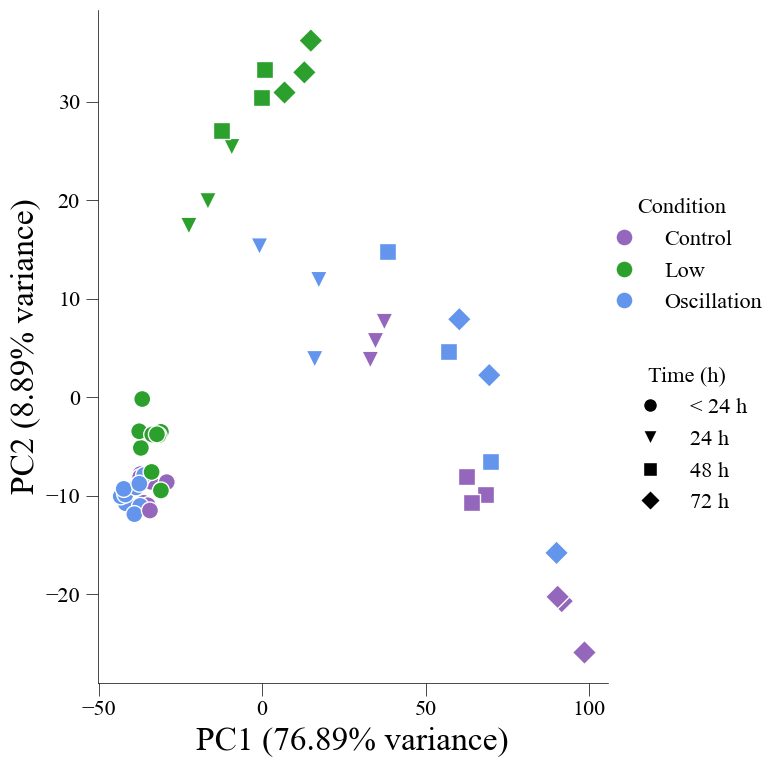

In [30]:

features = phospho.T
pca_df, explained_variance = pca_preprocess(features)
features['Condition'] = features.index.map(prot_condition_dict)
# features['Timepoint'] = features.index.map(prot_timepoint_dict)
features['Timepoint'] = features.index.map(prot_timepoint_dict_2)

pca_df['Condition'] = features['Condition'].values
pca_df['Timepoint'] = features['Timepoint'].values


pca_df['Batch']=0
# pca_df[pca_df.index<15]['Batch']=1
# pca_df['Reactor'] = df['Reactor'].values
pca_df.loc[pca_df.index <= 17, 'Batch'] = 1
pca_df.loc[pca_df.index > 17, 'Batch'] = 2
plot_pca(pca_df, explained_variance,title='pca_redox_condition')


# Differential Expression of Global Prot. 

## Compare Control late vs early.

In [31]:
# grab the redox data. 
prot = annotated_phospho[sample_ids_prot_redox]
prot['Protein'] = annotated_phospho['Protein']
prot['ProteinID'] = annotated_phospho['Protein'].copy()
prot.index = annotated_phospho['Site']

# drop oscillations, low. 
prot_control_late_vs_early_combined = prot.drop(prot.columns[prot.columns.str.contains("Oscillation|Low")], axis=1)


/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/3233933384.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot['Protein'] = annotated_phospho['Protein']
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/3233933384.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot['ProteinID'] = annotated_phospho['Protein'].copy()


In [32]:
prot_control_late_vs_early_combined.columns

Index(['Biostat2L_30_Control_3.5', 'Biostat2L_30_Control_4.5',
       'Biostat2L_30_Control_5.5', 'Biostat2L_30_Control_24',
       'Biostat2L_30_Control_48', 'Biostat2L_30_Control_72',
       'Biostat2L_31_Control_3.5', 'Biostat2L_31_Control_4.5',
       'Biostat2L_31_Control_5.5', 'Biostat2L_31_Control_24',
       'Biostat2L_31_Control_48', 'Biostat2L_31_Control_72',
       'Biostat2L_32_Control_3.5', 'Biostat2L_32_Control_4.5',
       'Biostat2L_32_Control_5.5', 'Biostat2L_32_Control_24',
       'Biostat2L_32_Control_48', 'Biostat2L_32_Control_72', 'Protein',
       'ProteinID'],
      dtype='object')

In [33]:
# prot_timepoint_dict initialized in annotation section. 
prot_condition_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['condition']))


### Prep for p-values. 

In [34]:
# group for mapping in nanova. 
condition_series = pd.Series(prot_control_late_vs_early_combined.columns).map(prot_timepoint_dict)
condition_series.index = prot_control_late_vs_early_combined.columns
condition_series 




Biostat2L_30_Control_3.5    Early
Biostat2L_30_Control_4.5    Early
Biostat2L_30_Control_5.5    Early
Biostat2L_30_Control_24      Late
Biostat2L_30_Control_48      Late
Biostat2L_30_Control_72      Late
Biostat2L_31_Control_3.5    Early
Biostat2L_31_Control_4.5    Early
Biostat2L_31_Control_5.5    Early
Biostat2L_31_Control_24      Late
Biostat2L_31_Control_48      Late
Biostat2L_31_Control_72      Late
Biostat2L_32_Control_3.5    Early
Biostat2L_32_Control_4.5    Early
Biostat2L_32_Control_5.5    Early
Biostat2L_32_Control_24      Late
Biostat2L_32_Control_48      Late
Biostat2L_32_Control_72      Late
Protein                       NaN
ProteinID                     NaN
dtype: object

In [35]:
# calculate p-values. 
prot_control_late_vs_early_combined_stats = global_stats_calc_prot(prot_control_late_vs_early_combined,condition_series)


In [36]:
prot_control_late_vs_early_combined_stats

,Site,Biostat2L_30_Control_3.5,Biostat2L_30_Control_4.5,Biostat2L_30_Control_5.5,Biostat2L_30_Control_24,Biostat2L_30_Control_48,Biostat2L_30_Control_72,Biostat2L_31_Control_3.5,Biostat2L_31_Control_4.5,Biostat2L_31_Control_5.5,...,Biostat2L_32_Control_3.5,Biostat2L_32_Control_4.5,Biostat2L_32_Control_5.5,Biostat2L_32_Control_24,Biostat2L_32_Control_48,Biostat2L_32_Control_72,Protein,ProteinID,ANOVA_p,ANOVA_padj
0,jgi|YarliW29_1|1012@T748,12.673789,12.174665,12.784090,13.787372,14.073101,13.139452,13.440964,12.765363,12.955787,...,12.936020,12.765731,12.660501,13.571825,13.513770,13.580512,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,1.944688e-05,4.690131e-05
1,jgi|YarliW29_1|1029@S1108,14.076738,14.560468,14.123239,14.986167,15.273361,15.055229,14.154478,14.334222,14.303263,...,13.654126,14.414255,14.726615,14.785028,14.819879,14.811235,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,1.457279e-05,3.651293e-05
2,jgi|YarliW29_1|1029@S212,13.069854,13.332494,13.366579,14.699762,14.329749,14.208659,13.769032,13.599552,13.408821,...,12.506573,13.314957,13.328912,13.936396,14.696044,14.338431,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,5.039577e-06,1.456955e-05
3,jgi|YarliW29_1|1029@S225,17.829095,18.111247,18.440744,19.030934,19.312877,19.436340,18.317856,18.115729,18.198653,...,17.741004,18.138030,18.215223,18.683641,19.453357,19.281014,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,4.347879e-07,1.647810e-06
4,jgi|YarliW29_1|1029@S368,16.825546,16.932283,17.511132,17.105610,17.644165,17.407525,17.101510,17.465836,17.810798,...,16.457102,17.264963,17.439530,16.853587,17.659650,17.554265,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,2.611352e-01,3.051088e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,jgi|YarliW29_1|868@S383,10.774548,NaN,10.308301,NaN,NaN,NaN,NaN,NaN,10.442978,...,NaN,10.989316,NaN,NaN,NaN,NaN,jgi|YarliW29_1|868,jgi|YarliW29_1|868,4.549612e-01,4.992397e-01
453,jgi|YarliW29_1|930@S188,14.141160,13.741552,14.411935,14.912793,15.620293,15.553742,14.257876,13.993590,14.163506,...,14.242461,14.525689,14.186452,15.133290,15.056103,15.360002,jgi|YarliW29_1|930,jgi|YarliW29_1|930,8.949123e-08,3.996093e-07
454,jgi|YarliW29_1|965@S260,14.503131,14.262400,14.364013,15.165872,15.619454,15.664237,14.718338,14.511029,14.433241,...,14.345546,14.412083,14.616176,15.208554,15.554385,15.498715,jgi|YarliW29_1|965,jgi|YarliW29_1|965,3.757999e-10,4.460152e-09
455,jgi|YarliW29_1|971@S12,14.152041,13.508958,14.011627,14.777946,15.657588,15.659934,14.128689,14.063924,13.880465,...,13.940774,14.080348,13.923460,14.771296,15.062128,15.564438,jgi|YarliW29_1|971,jgi|YarliW29_1|971,7.061980e-08,3.283456e-07


In [37]:
# Extract the number between "YarliW29_1|" and "@GLB" using regex
prot_control_late_vs_early_combined_stats["proteinID"] = prot_control_late_vs_early_combined_stats["Site"].str.extract(r"YarliW29_1\|(\d+)@")

# Convert the extracted number to integer (if needed)
prot_control_late_vs_early_combined_stats["proteinID"] = prot_control_late_vs_early_combined_stats["proteinID"].astype(int)


In [38]:
prot_control_late_vs_early_combined_stats

,Site,Biostat2L_30_Control_3.5,Biostat2L_30_Control_4.5,Biostat2L_30_Control_5.5,Biostat2L_30_Control_24,Biostat2L_30_Control_48,Biostat2L_30_Control_72,Biostat2L_31_Control_3.5,Biostat2L_31_Control_4.5,Biostat2L_31_Control_5.5,...,Biostat2L_32_Control_4.5,Biostat2L_32_Control_5.5,Biostat2L_32_Control_24,Biostat2L_32_Control_48,Biostat2L_32_Control_72,Protein,ProteinID,ANOVA_p,ANOVA_padj,proteinID
0,jgi|YarliW29_1|1012@T748,12.673789,12.174665,12.784090,13.787372,14.073101,13.139452,13.440964,12.765363,12.955787,...,12.765731,12.660501,13.571825,13.513770,13.580512,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,1.944688e-05,4.690131e-05,1012
1,jgi|YarliW29_1|1029@S1108,14.076738,14.560468,14.123239,14.986167,15.273361,15.055229,14.154478,14.334222,14.303263,...,14.414255,14.726615,14.785028,14.819879,14.811235,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,1.457279e-05,3.651293e-05,1029
2,jgi|YarliW29_1|1029@S212,13.069854,13.332494,13.366579,14.699762,14.329749,14.208659,13.769032,13.599552,13.408821,...,13.314957,13.328912,13.936396,14.696044,14.338431,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,5.039577e-06,1.456955e-05,1029
3,jgi|YarliW29_1|1029@S225,17.829095,18.111247,18.440744,19.030934,19.312877,19.436340,18.317856,18.115729,18.198653,...,18.138030,18.215223,18.683641,19.453357,19.281014,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,4.347879e-07,1.647810e-06,1029
4,jgi|YarliW29_1|1029@S368,16.825546,16.932283,17.511132,17.105610,17.644165,17.407525,17.101510,17.465836,17.810798,...,17.264963,17.439530,16.853587,17.659650,17.554265,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,2.611352e-01,3.051088e-01,1029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,jgi|YarliW29_1|868@S383,10.774548,NaN,10.308301,NaN,NaN,NaN,NaN,NaN,10.442978,...,10.989316,NaN,NaN,NaN,NaN,jgi|YarliW29_1|868,jgi|YarliW29_1|868,4.549612e-01,4.992397e-01,868
453,jgi|YarliW29_1|930@S188,14.141160,13.741552,14.411935,14.912793,15.620293,15.553742,14.257876,13.993590,14.163506,...,14.525689,14.186452,15.133290,15.056103,15.360002,jgi|YarliW29_1|930,jgi|YarliW29_1|930,8.949123e-08,3.996093e-07,930
454,jgi|YarliW29_1|965@S260,14.503131,14.262400,14.364013,15.165872,15.619454,15.664237,14.718338,14.511029,14.433241,...,14.412083,14.616176,15.208554,15.554385,15.498715,jgi|YarliW29_1|965,jgi|YarliW29_1|965,3.757999e-10,4.460152e-09,965
455,jgi|YarliW29_1|971@S12,14.152041,13.508958,14.011627,14.777946,15.657588,15.659934,14.128689,14.063924,13.880465,...,14.080348,13.923460,14.771296,15.062128,15.564438,jgi|YarliW29_1|971,jgi|YarliW29_1|971,7.061980e-08,3.283456e-07,971


In [39]:
prot_control_late_vs_early_combined_stats.head()

,Site,Biostat2L_30_Control_3.5,Biostat2L_30_Control_4.5,Biostat2L_30_Control_5.5,Biostat2L_30_Control_24,Biostat2L_30_Control_48,Biostat2L_30_Control_72,Biostat2L_31_Control_3.5,Biostat2L_31_Control_4.5,Biostat2L_31_Control_5.5,...,Biostat2L_32_Control_4.5,Biostat2L_32_Control_5.5,Biostat2L_32_Control_24,Biostat2L_32_Control_48,Biostat2L_32_Control_72,Protein,ProteinID,ANOVA_p,ANOVA_padj,proteinID
0,jgi|YarliW29_1|1012@T748,12.673789,12.174665,12.784090,13.787372,14.073101,13.139452,13.440964,12.765363,12.955787,...,12.765731,12.660501,13.571825,13.513770,13.580512,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,1.944688e-05,0.000047,1012
1,jgi|YarliW29_1|1029@S1108,14.076738,14.560468,14.123239,14.986167,15.273361,15.055229,14.154478,14.334222,14.303263,...,14.414255,14.726615,14.785028,14.819879,14.811235,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,1.457279e-05,0.000037,1029
2,jgi|YarliW29_1|1029@S212,13.069854,13.332494,13.366579,14.699762,14.329749,14.208659,13.769032,13.599552,13.408821,...,13.314957,13.328912,13.936396,14.696044,14.338431,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,5.039577e-06,0.000015,1029
3,jgi|YarliW29_1|1029@S225,17.829095,18.111247,18.440744,19.030934,19.312877,19.436340,18.317856,18.115729,18.198653,...,18.138030,18.215223,18.683641,19.453357,19.281014,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,4.347879e-07,0.000002,1029
4,jgi|YarliW29_1|1029@S368,16.825546,16.932283,17.511132,17.105610,17.644165,17.407525,17.101510,17.465836,17.810798,...,17.264963,17.439530,16.853587,17.659650,17.554265,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,2.611352e-01,0.305109,1029


### calculate log2FC

In [40]:
early = prot_control_late_vs_early_combined_stats.loc[:, prot_control_late_vs_early_combined_stats.columns[prot_control_late_vs_early_combined_stats.columns.str.contains("3.5|4.5|5.5")]]
early.head()

# 24 h


,Biostat2L_30_Control_3.5,Biostat2L_30_Control_4.5,Biostat2L_30_Control_5.5,Biostat2L_31_Control_3.5,Biostat2L_31_Control_4.5,Biostat2L_31_Control_5.5,Biostat2L_32_Control_3.5,Biostat2L_32_Control_4.5,Biostat2L_32_Control_5.5
0,12.673789,12.174665,12.784090,13.440964,12.765363,12.955787,12.936020,12.765731,12.660501
1,14.076738,14.560468,14.123239,14.154478,14.334222,14.303263,13.654126,14.414255,14.726615
2,13.069854,13.332494,13.366579,13.769032,13.599552,13.408821,12.506573,13.314957,13.328912
3,17.829095,18.111247,18.440744,18.317856,18.115729,18.198653,17.741004,18.138030,18.215223
4,16.825546,16.932283,17.511132,17.101510,17.465836,17.810798,16.457102,17.264963,17.439530


In [41]:
late = prot_control_late_vs_early_combined_stats.loc[:, prot_control_late_vs_early_combined_stats.columns[prot_control_late_vs_early_combined_stats.columns.str.contains("24|48|72")]]
late.head()

# 24 h


,Biostat2L_30_Control_24,Biostat2L_30_Control_48,Biostat2L_30_Control_72,Biostat2L_31_Control_24,Biostat2L_31_Control_48,Biostat2L_31_Control_72,Biostat2L_32_Control_24,Biostat2L_32_Control_48,Biostat2L_32_Control_72
0,13.787372,14.073101,13.139452,13.584965,13.975370,13.641081,13.571825,13.513770,13.580512
1,14.986167,15.273361,15.055229,14.881975,15.121685,15.129808,14.785028,14.819879,14.811235
2,14.699762,14.329749,14.208659,13.898204,14.799473,14.519338,13.936396,14.696044,14.338431
3,19.030934,19.312877,19.436340,18.626579,19.306227,19.186372,18.683641,19.453357,19.281014
4,17.105610,17.644165,17.407525,17.154443,17.636363,17.564225,16.853587,17.659650,17.554265


In [42]:
# gives the increase of the first. 
prot_control_late_vs_early_combined_stats['log2FC']=log2FC_function(early,late)


In [43]:
df_to_merge = pd.DataFrame()
df_to_merge['early/late'] = prot_control_late_vs_early_combined_stats['log2FC']
df_to_merge['Site'] = prot_control_late_vs_early_combined_stats['Site']
df_to_merge['early/late_ANOVA_padj'] = prot_control_late_vs_early_combined_stats['ANOVA_padj']
df_to_merge['early/late_ANOVA_p'] = prot_control_late_vs_early_combined_stats['ANOVA_p']


In [44]:
df_to_merge

,early/late,Site,early/late_ANOVA_padj,early/late_ANOVA_p
0,-0.856726,jgi|YarliW29_1|1012@T748,4.690131e-05,1.944688e-05
1,-0.724107,jgi|YarliW29_1|1029@S1108,3.651293e-05,1.457279e-05
2,-1.081031,jgi|YarliW29_1|1029@S212,1.456955e-05,5.039577e-06
3,-1.023307,jgi|YarliW29_1|1029@S225,1.647810e-06,4.347879e-07
4,-0.196793,jgi|YarliW29_1|1029@S368,3.051088e-01,2.611352e-01
...,...,...,...,...
452,-0.296738,jgi|YarliW29_1|868@S383,4.992397e-01,4.549612e-01
453,-1.108683,jgi|YarliW29_1|930@S188,3.996093e-07,8.949123e-08
454,-1.021961,jgi|YarliW29_1|965@S260,4.460152e-09,3.757999e-10
455,-1.277760,jgi|YarliW29_1|971@S12,3.283456e-07,7.061980e-08


In [45]:
df_to_merge.columns

Index(['early/late', 'Site', 'early/late_ANOVA_padj', 'early/late_ANOVA_p'], dtype='object')

In [46]:

merged_df = pd.merge(annotated_phospho, df_to_merge, left_on='Site',right_on='Site', how='left')

In [47]:
merged_df.head(20)

,Peptide,Site,UniProt,Protein,Residue,AScore,id,Total missingness,Oscillation_24 missingness,Oscillation_3.5 missingness,...,gotermType,goAcc,#transcriptId,kogid,kogdefline,kogClass,kogGroup,early/late,early/late_ANOVA_padj,early/late_ANOVA_p
0,K.LAEENTSEAIFDTPDT#DEDDAK.S,jgi|YarliW29_1|1012@T748,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,T748,43.40600,jgi|YarliW29_1|1012@T748,18,0,0,...,"molecular_function, cellular_component, biolog...","GO:0005097, GO:0005622, GO:0032313",1990.0,KOG4347,GTPase-activating protein VRP,General function prediction only,POORLY CHARACTERIZED,-0.856726,4.690131e-05,1.944688e-05
1,R.SNS#MSAFR.M,jgi|YarliW29_1|1029@S1108,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S1108,22.21700,jgi|YarliW29_1|1029@S1108,18,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.724107,3.651293e-05,1.457279e-05
2,R.RGS#MTSTTTNTER.T,jgi|YarliW29_1|1029@S212,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S212,45.54300,jgi|YarliW29_1|1029@S212,36,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.081031,1.456955e-05,5.039577e-06
3,R.THS#LTSTTTTIK.R; R.THS#LTSTTTTIKR.M,jgi|YarliW29_1|1029@S225,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S225,28.74600,jgi|YarliW29_1|1029@S225,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.023307,1.647810e-06,4.347879e-07
4,R.TLS#PM*KPALK.M; R.TLS#PMKPALK.M,jgi|YarliW29_1|1029@S368,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S368,1000.00000,jgi|YarliW29_1|1029@S368,18,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.196793,3.051088e-01,2.611352e-01
5,R.ANS#GLSSAAAAAAIR.H,jgi|YarliW29_1|1029@S49,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S49,107.28000,jgi|YarliW29_1|1029@S49,5,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.656691,6.284172e-05,2.647434e-05
6,R.QAAPAPPSQVLSPM*LS#HSESEEDLSMFQDAHEHLGK.S,jgi|YarliW29_1|1029@S559,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S559,23.94200,jgi|YarliW29_1|1029@S559,49,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.129958,8.865105e-01,8.609570e-01
7,R.HHS#LTSSTSQPNLQQGR.N,jgi|YarliW29_1|1029@S64,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S64,45.54300,jgi|YarliW29_1|1029@S64,37,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.161774,1.456850e-03,8.075666e-04
8,K.T#PGGAAQHFLDDDDYFSR.G,jgi|YarliW29_1|1049@T925,jgi|YarliW29_1|1049,jgi|YarliW29_1|1049,T925,256.78000,jgi|YarliW29_1|1049@T925,1,0,1,...,"molecular_function, biological_process","GO:0004573, GO:0009311, GO:0003824",2027.0,KOG2161,Glucosidase I,Carbohydrate transport and metabolism,METABOLISM,-1.337130,1.078196e-03,5.857162e-04
9,K.LHDVANSPYQSS#PR.T,jgi|YarliW29_1|1051@S540,jgi|YarliW29_1|1051,jgi|YarliW29_1|1051,S540,0.00000,jgi|YarliW29_1|1051@S540,19,3,3,...,molecular_function,"GO:0016773, GO:0004428, GO:0005488, GO:0004430",2029.0,KOG0903,"Phosphatidylinositol 4-kinase, involved in int...","Signal transduction mechanisms, Intracellular ...",CELLULAR PROCESSES AND SIGNALING,-0.705503,4.881143e-03,2.933015e-03


In [48]:
prot_control_late_vs_early_combined_stats_withAnnote = pd.merge(prot_control_late_vs_early_combined_stats, merged_annotations, left_on='proteinID', right_on='#proteinId', how='left')


### optional save. 

In [49]:
# prot_control_late_vs_early_combined_stats_withAnnote.to_csv('early_vs_late.csv')

### Volcano plot comparing late vs early.
all late (increase means increased in low)


In [55]:
dataset = prot_control_late_vs_early_combined_stats_withAnnote[['log2FC', 'ANOVA_p']].copy()
dataset.index = prot_control_late_vs_early_combined_stats_withAnnote.Site

In [56]:
log2FC_threshold = np.log2(1.3)

In [57]:
dataset

,log2FC,ANOVA_p
Site,,
jgi|YarliW29_1|1012@T748,-0.856726,1.944688e-05
jgi|YarliW29_1|1029@S1108,-0.724107,1.457279e-05
jgi|YarliW29_1|1029@S212,-1.081031,5.039577e-06
jgi|YarliW29_1|1029@S225,-1.023307,4.347879e-07
jgi|YarliW29_1|1029@S368,-0.196793,2.611352e-01
...,...,...
jgi|YarliW29_1|868@S383,-0.296738,4.549612e-01
jgi|YarliW29_1|930@S188,-1.108683,8.949123e-08
jgi|YarliW29_1|965@S260,-1.021961,3.757999e-10


In [58]:
# subset the log2FC and the P_value for this dataset. 
dataset.columns = ['log2FC','P_value']

# obtain the -logP_adj for the dataset. 
dataset['-logP_adj'] = -np.log10(dataset['P_value'])

# set a class for up (1) or down (-1) proteins. 
dataset['class'] = 0
dataset.loc[(dataset['log2FC']>log2FC_threshold)&(dataset['-logP_adj']>-np.log10(0.05)),'class'] = 1
dataset.loc[(dataset['log2FC']<-log2FC_threshold)&(dataset['-logP_adj']>-np.log10(0.05)),'class'] = -1

/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:202: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_min = df.min()[0]-1
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:203: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_max = df.max()[0]+1
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:206: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_

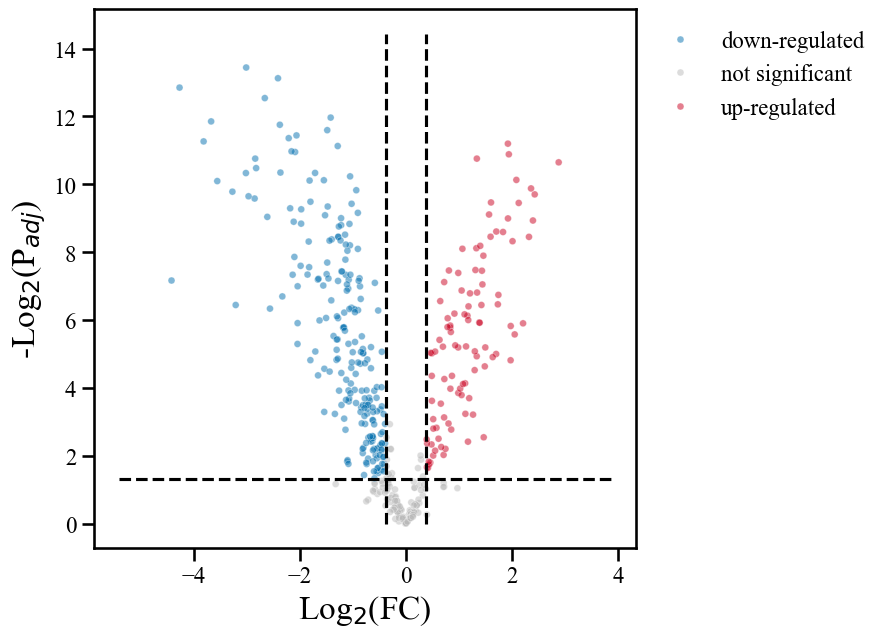

In [59]:
volcano_plot(dataset)

## Compare Control vs low. 

In [60]:
prot = annotated_phospho[sample_ids_prot_redox]
prot['Protein'] = annotated_phospho['Site']
prot.index = annotated_phospho['Site']
# drop oscillations.
prot_control_vs_low_late_combined = prot.drop(prot.columns[prot.columns.str.contains("Oscillation")], axis=1)
# prot_control_vs_oscillation_late_combined = prot.drop(prot.columns[prot.columns.str.contains("Low")], axis=1)
prot_control_vs_low_24h = prot.drop(prot.columns[prot.columns.str.contains("Oscillation")], axis=1)


# drop early timepoints. 
prot_control_vs_low_late_combined = prot_control_vs_low_late_combined.drop(prot_control_vs_low_late_combined.columns[
    prot_control_vs_low_late_combined.columns.str.contains("5.5|3.5|4.5")], axis=1)

# prot_control_vs_low_24h = prot_control_vs_low_24h.drop(prot_control_vs_low_24h.columns[
#     prot_control_vs_low_24h.columns.str.contains("5.5|3.5|4.5|48|72")], axis=1)


 

/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/3895769385.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot['Protein'] = annotated_phospho['Site']


In [61]:
prot_control_vs_low_late_combined.columns

Index(['Biostat2L_30_Control_24', 'Biostat2L_30_Control_48',
       'Biostat2L_30_Control_72', 'Biostat2L_31_Control_24',
       'Biostat2L_31_Control_48', 'Biostat2L_31_Control_72',
       'Biostat2L_32_Control_24', 'Biostat2L_32_Control_48',
       'Biostat2L_32_Control_72', 'Biostat2L_32_Low_24', 'Biostat2L_32_Low_48',
       'Biostat2L_32_Low_72', 'Biostat2L_33_Low_24', 'Biostat2L_33_Low_48',
       'Biostat2L_33_Low_72', 'Biostat2L_34_Low_24', 'Biostat2L_34_Low_48',
       'Biostat2L_34_Low_72', 'Protein'],
      dtype='object')

In [62]:
prot_condition_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['condition']))
prot_timepoint_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['timepoint']))

### Prep for p-values. 

In [63]:
# group for mapping in nanova. 
condition_series = pd.Series(prot_control_vs_low_late_combined.columns).map(prot_condition_dict)
condition_series.index = prot_control_vs_low_late_combined.columns
condition_series 

condition_series24h = pd.Series(prot_control_vs_low_24h.columns).map(prot_condition_dict)
condition_series24h.index = prot_control_vs_low_24h.columns
condition_series24h 



Biostat2L_30_Control_3.5    Control
Biostat2L_30_Control_4.5    Control
Biostat2L_30_Control_5.5    Control
Biostat2L_30_Control_24     Control
Biostat2L_30_Control_48     Control
Biostat2L_30_Control_72     Control
Biostat2L_31_Control_3.5    Control
Biostat2L_31_Control_4.5    Control
Biostat2L_31_Control_5.5    Control
Biostat2L_31_Control_24     Control
Biostat2L_31_Control_48     Control
Biostat2L_31_Control_72     Control
Biostat2L_32_Control_3.5    Control
Biostat2L_32_Control_4.5    Control
Biostat2L_32_Control_5.5    Control
Biostat2L_32_Control_24     Control
Biostat2L_32_Control_48     Control
Biostat2L_32_Control_72     Control
Biostat2L_32_Low_3.5            Low
Biostat2L_32_Low_4.5            Low
Biostat2L_32_Low_5.5            Low
Biostat2L_32_Low_24             Low
Biostat2L_32_Low_48             Low
Biostat2L_32_Low_72             Low
Biostat2L_33_Low_3.5            Low
Biostat2L_33_Low_4.5            Low
Biostat2L_33_Low_5.5            Low
Biostat2L_33_Low_24         

In [64]:
prot.head()

,Biostat2L_29_Oscillation_3.5,Biostat2L_29_Oscillation_4.5,Biostat2L_29_Oscillation_5.5,Biostat2L_29_Oscillation_24,Biostat2L_29_Oscillation_48,Biostat2L_29_Oscillation_72,Biostat2L_30_Control_3.5,Biostat2L_30_Control_4.5,Biostat2L_30_Control_5.5,Biostat2L_30_Control_24,...,Biostat2L_33_Low_24,Biostat2L_33_Low_48,Biostat2L_33_Low_72,Biostat2L_34_Low_3.5,Biostat2L_34_Low_4.5,Biostat2L_34_Low_5.5,Biostat2L_34_Low_24,Biostat2L_34_Low_48,Biostat2L_34_Low_72,Protein
Site,,,,,,,,,,,,,,,,,,,,,
jgi|YarliW29_1|1012@T748,12.221481,12.249952,13.431107,13.921812,14.148031,13.556648,12.673789,12.174665,12.784090,13.787372,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1012@T748
jgi|YarliW29_1|1029@S1108,14.374154,14.303978,14.345682,14.687903,14.764124,14.143469,14.076738,14.560468,14.123239,14.986167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1029@S1108
jgi|YarliW29_1|1029@S212,NaN,NaN,NaN,NaN,NaN,NaN,13.069854,13.332494,13.366579,14.699762,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1029@S212
jgi|YarliW29_1|1029@S225,18.100242,17.731381,17.530926,18.450295,19.224261,19.409963,17.829095,18.111247,18.440744,19.030934,...,19.560714,19.514274,19.683966,18.893723,18.824457,19.094217,19.120369,19.430804,19.867831,jgi|YarliW29_1|1029@S225
jgi|YarliW29_1|1029@S368,NaN,NaN,NaN,NaN,NaN,NaN,16.825546,16.932283,17.511132,17.105610,...,16.512579,16.373739,15.780137,17.111359,17.149535,17.474933,17.059593,16.416683,16.037147,jgi|YarliW29_1|1029@S368


In [65]:
# calculate p-values. 
prot_control_vs_low_late_combined_stats = global_stats_calc_prot(prot_control_vs_low_late_combined,condition_series)
# prot_control_vs_low_24h_stats = global_stats_calc_prot(prot_control_vs_low_24h,condition_series24h)


# prot_control_vs_oscillation_late_combined_stats = global_stats_calc_prot(prot_control_vs_oscillation_late_combined,condition_series_controlvsOsc )
# prot_control_late_vs_control_early_stats = global_stats_calc_prot(prot_control_late_vs_control_early,condition_series_controlLateVsEarly)


In [66]:
prot_control_vs_low_late_combined_stats.head()

,Site,Biostat2L_30_Control_24,Biostat2L_30_Control_48,Biostat2L_30_Control_72,Biostat2L_31_Control_24,Biostat2L_31_Control_48,Biostat2L_31_Control_72,Biostat2L_32_Control_24,Biostat2L_32_Control_48,Biostat2L_32_Control_72,...,Biostat2L_32_Low_72,Biostat2L_33_Low_24,Biostat2L_33_Low_48,Biostat2L_33_Low_72,Biostat2L_34_Low_24,Biostat2L_34_Low_48,Biostat2L_34_Low_72,Protein,ANOVA_p,ANOVA_padj
0,jgi|YarliW29_1|1012@T748,13.787372,14.073101,13.139452,13.584965,13.975370,13.641081,13.571825,13.513770,13.580512,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1012@T748,NaN,NaN
1,jgi|YarliW29_1|1029@S1108,14.986167,15.273361,15.055229,14.881975,15.121685,15.129808,14.785028,14.819879,14.811235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1029@S1108,NaN,NaN
2,jgi|YarliW29_1|1029@S212,14.699762,14.329749,14.208659,13.898204,14.799473,14.519338,13.936396,14.696044,14.338431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1029@S212,NaN,NaN
3,jgi|YarliW29_1|1029@S225,19.030934,19.312877,19.436340,18.626579,19.306227,19.186372,18.683641,19.453357,19.281014,...,19.928461,19.560714,19.514274,19.683966,19.120369,19.430804,19.867831,jgi|YarliW29_1|1029@S225,0.011606,0.020056
4,jgi|YarliW29_1|1029@S368,17.105610,17.644165,17.407525,17.154443,17.636363,17.564225,16.853587,17.659650,17.554265,...,16.183309,16.512579,16.373739,15.780137,17.059593,16.416683,16.037147,jgi|YarliW29_1|1029@S368,0.000006,0.000030


In [67]:
# Extract the number between "YarliW29_1|" and "@GLB" using regex
prot_control_vs_low_late_combined_stats["proteinID"] = prot_control_vs_low_late_combined_stats["Site"].str.extract(r"YarliW29_1\|(\d+)@")
# prot_control_vs_low_24h_stats["proteinID"] = prot_control_vs_low_24h_stats["Protein"].str.extract(r"YarliW29_1\|(\d+)@GLB")

# Convert the extracted number to integer (if needed)
prot_control_vs_low_late_combined_stats["proteinID"] = prot_control_vs_low_late_combined_stats["proteinID"].astype(int)
# prot_control_vs_low_24h_stats["proteinID"] = prot_control_vs_low_24h_stats["proteinID"].astype(int)


In [68]:
prot_control_vs_low_late_combined_stats.head()

,Site,Biostat2L_30_Control_24,Biostat2L_30_Control_48,Biostat2L_30_Control_72,Biostat2L_31_Control_24,Biostat2L_31_Control_48,Biostat2L_31_Control_72,Biostat2L_32_Control_24,Biostat2L_32_Control_48,Biostat2L_32_Control_72,...,Biostat2L_33_Low_24,Biostat2L_33_Low_48,Biostat2L_33_Low_72,Biostat2L_34_Low_24,Biostat2L_34_Low_48,Biostat2L_34_Low_72,Protein,ANOVA_p,ANOVA_padj,proteinID
0,jgi|YarliW29_1|1012@T748,13.787372,14.073101,13.139452,13.584965,13.975370,13.641081,13.571825,13.513770,13.580512,...,NaN,NaN,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1012@T748,NaN,NaN,1012
1,jgi|YarliW29_1|1029@S1108,14.986167,15.273361,15.055229,14.881975,15.121685,15.129808,14.785028,14.819879,14.811235,...,NaN,NaN,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1029@S1108,NaN,NaN,1029
2,jgi|YarliW29_1|1029@S212,14.699762,14.329749,14.208659,13.898204,14.799473,14.519338,13.936396,14.696044,14.338431,...,NaN,NaN,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1029@S212,NaN,NaN,1029
3,jgi|YarliW29_1|1029@S225,19.030934,19.312877,19.436340,18.626579,19.306227,19.186372,18.683641,19.453357,19.281014,...,19.560714,19.514274,19.683966,19.120369,19.430804,19.867831,jgi|YarliW29_1|1029@S225,0.011606,0.020056,1029
4,jgi|YarliW29_1|1029@S368,17.105610,17.644165,17.407525,17.154443,17.636363,17.564225,16.853587,17.659650,17.554265,...,16.512579,16.373739,15.780137,17.059593,16.416683,16.037147,jgi|YarliW29_1|1029@S368,0.000006,0.000030,1029


### calculate log2FC

In [69]:
control = prot_control_vs_low_late_combined_stats.loc[:, prot_control_vs_low_late_combined_stats.columns[prot_control_vs_low_late_combined_stats.columns.str.contains("Control")]]
control.head()

# 24 h
# control24h = prot_control_vs_low_24h_stats.loc[:, prot_control_vs_low_24h_stats.columns[prot_control_vs_low_24h_stats.columns.str.contains("Control")]]
# control24h.head()

,Biostat2L_30_Control_24,Biostat2L_30_Control_48,Biostat2L_30_Control_72,Biostat2L_31_Control_24,Biostat2L_31_Control_48,Biostat2L_31_Control_72,Biostat2L_32_Control_24,Biostat2L_32_Control_48,Biostat2L_32_Control_72
0,13.787372,14.073101,13.139452,13.584965,13.975370,13.641081,13.571825,13.513770,13.580512
1,14.986167,15.273361,15.055229,14.881975,15.121685,15.129808,14.785028,14.819879,14.811235
2,14.699762,14.329749,14.208659,13.898204,14.799473,14.519338,13.936396,14.696044,14.338431
3,19.030934,19.312877,19.436340,18.626579,19.306227,19.186372,18.683641,19.453357,19.281014
4,17.105610,17.644165,17.407525,17.154443,17.636363,17.564225,16.853587,17.659650,17.554265


In [70]:
low = prot_control_vs_low_late_combined_stats.loc[:, prot_control_vs_low_late_combined_stats.columns[
    prot_control_vs_low_late_combined_stats.columns.str.contains("Low")]]
low.head()

# low24h = prot_control_vs_low_24h_stats.loc[:, prot_control_vs_low_24h_stats.columns[
    # prot_control_vs_low_24h_stats.columns.str.contains("Low")]]
# low24h.head()

,Biostat2L_32_Low_24,Biostat2L_32_Low_48,Biostat2L_32_Low_72,Biostat2L_33_Low_24,Biostat2L_33_Low_48,Biostat2L_33_Low_72,Biostat2L_34_Low_24,Biostat2L_34_Low_48,Biostat2L_34_Low_72
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,19.143275,19.618330,19.928461,19.560714,19.514274,19.683966,19.120369,19.430804,19.867831
4,16.613736,16.329088,16.183309,16.512579,16.373739,15.780137,17.059593,16.416683,16.037147


In [71]:
# gives the increase of the first. 
prot_control_vs_low_late_combined_stats['log2FC']=log2FC_function(low,control)
# prot_control_vs_low_24h_stats['log2FC']=log2FC_function(low24h,control24h)


In [72]:
prot_control_vs_low_late_combined_stats['proteinId'] = prot_control_vs_low_late_combined_stats['proteinID']

In [73]:
df_to_merge = pd.DataFrame()
df_to_merge['low/control_late_combined'] = prot_control_vs_low_late_combined_stats['log2FC']
df_to_merge['Site'] = prot_control_vs_low_late_combined_stats['Site']
df_to_merge['low/control_late_combined_ANOVA_padj'] = prot_control_vs_low_late_combined_stats['ANOVA_padj']
df_to_merge['low/control_late_combined_ANOVA_p'] = prot_control_vs_low_late_combined_stats['ANOVA_p']


In [74]:
df_to_merge

,low/control_late_combined,Site,low/control_late_combined_ANOVA_padj,low/control_late_combined_ANOVA_p
0,NaN,jgi|YarliW29_1|1012@T748,NaN,NaN
1,NaN,jgi|YarliW29_1|1029@S1108,NaN,NaN
2,NaN,jgi|YarliW29_1|1029@S212,NaN,NaN
3,0.394520,jgi|YarliW29_1|1029@S225,0.020056,0.011606
4,-1.030425,jgi|YarliW29_1|1029@S368,0.000030,0.000006
...,...,...,...,...
452,NaN,jgi|YarliW29_1|868@S383,NaN,NaN
453,NaN,jgi|YarliW29_1|930@S188,NaN,NaN
454,-0.244271,jgi|YarliW29_1|965@S260,0.085368,0.057072
455,NaN,jgi|YarliW29_1|971@S12,NaN,NaN


In [75]:
merged_df = pd.merge(merged_df, df_to_merge, left_on='Site',right_on='Site', how='left')

In [76]:
merged_df.head(20)

,Peptide,Site,UniProt,Protein,Residue,AScore,id,Total missingness,Oscillation_24 missingness,Oscillation_3.5 missingness,...,kogid,kogdefline,kogClass,kogGroup,early/late,early/late_ANOVA_padj,early/late_ANOVA_p,low/control_late_combined,low/control_late_combined_ANOVA_padj,low/control_late_combined_ANOVA_p
0,K.LAEENTSEAIFDTPDT#DEDDAK.S,jgi|YarliW29_1|1012@T748,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,T748,43.40600,jgi|YarliW29_1|1012@T748,18,0,0,...,KOG4347,GTPase-activating protein VRP,General function prediction only,POORLY CHARACTERIZED,-0.856726,4.690131e-05,1.944688e-05,NaN,NaN,NaN
1,R.SNS#MSAFR.M,jgi|YarliW29_1|1029@S1108,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S1108,22.21700,jgi|YarliW29_1|1029@S1108,18,0,0,...,NaN,NaN,NaN,NaN,-0.724107,3.651293e-05,1.457279e-05,NaN,NaN,NaN
2,R.RGS#MTSTTTNTER.T,jgi|YarliW29_1|1029@S212,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S212,45.54300,jgi|YarliW29_1|1029@S212,36,3,3,...,NaN,NaN,NaN,NaN,-1.081031,1.456955e-05,5.039577e-06,NaN,NaN,NaN
3,R.THS#LTSTTTTIK.R; R.THS#LTSTTTTIKR.M,jgi|YarliW29_1|1029@S225,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S225,28.74600,jgi|YarliW29_1|1029@S225,0,0,0,...,NaN,NaN,NaN,NaN,-1.023307,1.647810e-06,4.347879e-07,0.394520,0.020056,0.011606
4,R.TLS#PM*KPALK.M; R.TLS#PMKPALK.M,jgi|YarliW29_1|1029@S368,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S368,1000.00000,jgi|YarliW29_1|1029@S368,18,3,3,...,NaN,NaN,NaN,NaN,-0.196793,3.051088e-01,2.611352e-01,-1.030425,0.000030,0.000006
5,R.ANS#GLSSAAAAAAIR.H,jgi|YarliW29_1|1029@S49,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S49,107.28000,jgi|YarliW29_1|1029@S49,5,0,1,...,NaN,NaN,NaN,NaN,-0.656691,6.284172e-05,2.647434e-05,-0.311865,0.054012,0.033378
6,R.QAAPAPPSQVLSPM*LS#HSESEEDLSMFQDAHEHLGK.S,jgi|YarliW29_1|1029@S559,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S559,23.94200,jgi|YarliW29_1|1029@S559,49,3,3,...,NaN,NaN,NaN,NaN,-0.129958,8.865105e-01,8.609570e-01,NaN,NaN,NaN
7,R.HHS#LTSSTSQPNLQQGR.N,jgi|YarliW29_1|1029@S64,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S64,45.54300,jgi|YarliW29_1|1029@S64,37,3,3,...,NaN,NaN,NaN,NaN,-1.161774,1.456850e-03,8.075666e-04,NaN,NaN,NaN
8,K.T#PGGAAQHFLDDDDYFSR.G,jgi|YarliW29_1|1049@T925,jgi|YarliW29_1|1049,jgi|YarliW29_1|1049,T925,256.78000,jgi|YarliW29_1|1049@T925,1,0,1,...,KOG2161,Glucosidase I,Carbohydrate transport and metabolism,METABOLISM,-1.337130,1.078196e-03,5.857162e-04,-1.404896,0.003578,0.001628
9,K.LHDVANSPYQSS#PR.T,jgi|YarliW29_1|1051@S540,jgi|YarliW29_1|1051,jgi|YarliW29_1|1051,S540,0.00000,jgi|YarliW29_1|1051@S540,19,3,3,...,KOG0903,"Phosphatidylinositol 4-kinase, involved in int...","Signal transduction mechanisms, Intracellular ...",CELLULAR PROCESSES AND SIGNALING,-0.705503,4.881143e-03,2.933015e-03,-1.072325,0.000064,0.000015


In [77]:
prot_control_vs_low_late_combined_stats.head()

,Site,Biostat2L_30_Control_24,Biostat2L_30_Control_48,Biostat2L_30_Control_72,Biostat2L_31_Control_24,Biostat2L_31_Control_48,Biostat2L_31_Control_72,Biostat2L_32_Control_24,Biostat2L_32_Control_48,Biostat2L_32_Control_72,...,Biostat2L_33_Low_72,Biostat2L_34_Low_24,Biostat2L_34_Low_48,Biostat2L_34_Low_72,Protein,ANOVA_p,ANOVA_padj,proteinID,log2FC,proteinId
0,jgi|YarliW29_1|1012@T748,13.787372,14.073101,13.139452,13.584965,13.975370,13.641081,13.571825,13.513770,13.580512,...,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1012@T748,NaN,NaN,1012,NaN,1012
1,jgi|YarliW29_1|1029@S1108,14.986167,15.273361,15.055229,14.881975,15.121685,15.129808,14.785028,14.819879,14.811235,...,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1029@S1108,NaN,NaN,1029,NaN,1029
2,jgi|YarliW29_1|1029@S212,14.699762,14.329749,14.208659,13.898204,14.799473,14.519338,13.936396,14.696044,14.338431,...,NaN,NaN,NaN,NaN,jgi|YarliW29_1|1029@S212,NaN,NaN,1029,NaN,1029
3,jgi|YarliW29_1|1029@S225,19.030934,19.312877,19.436340,18.626579,19.306227,19.186372,18.683641,19.453357,19.281014,...,19.683966,19.120369,19.430804,19.867831,jgi|YarliW29_1|1029@S225,0.011606,0.020056,1029,0.394520,1029
4,jgi|YarliW29_1|1029@S368,17.105610,17.644165,17.407525,17.154443,17.636363,17.564225,16.853587,17.659650,17.554265,...,15.780137,17.059593,16.416683,16.037147,jgi|YarliW29_1|1029@S368,0.000006,0.000030,1029,-1.030425,1029


In [78]:
prot_control_vs_low_late_combined_stats_withAnnote = pd.merge(prot_control_vs_low_late_combined_stats, merged_annotations, left_on='proteinID', right_on='#proteinId', how='left')
# prot_control_vs_low_24h_stats_withAnnote = pd.merge(prot_control_vs_low_24h_stats, merged_annotations, left_on='proteinID', right_on='#proteinId', how='left')

In [79]:
prot_control_vs_low_late_combined_stats_withAnnote.columns

Index(['Site', 'Biostat2L_30_Control_24', 'Biostat2L_30_Control_48',
       'Biostat2L_30_Control_72', 'Biostat2L_31_Control_24',
       'Biostat2L_31_Control_48', 'Biostat2L_31_Control_72',
       'Biostat2L_32_Control_24', 'Biostat2L_32_Control_48',
       'Biostat2L_32_Control_72', 'Biostat2L_32_Low_24', 'Biostat2L_32_Low_48',
       'Biostat2L_32_Low_72', 'Biostat2L_33_Low_24', 'Biostat2L_33_Low_48',
       'Biostat2L_33_Low_72', 'Biostat2L_34_Low_24', 'Biostat2L_34_Low_48',
       'Biostat2L_34_Low_72', 'Protein', 'ANOVA_p', 'ANOVA_padj', 'proteinID',
       'log2FC', 'proteinId', '#proteinId', 'kogid', 'kogdefline', 'kogClass',
       'kogGroup', 'definition', 'catalyticActivity', 'pathway',
       'pathway_class', 'pathway_type', 'ecNum', 'cofactors', 'gotermId',
       'gotermType', 'goName', 'goAcc'],
      dtype='object')

### optional save.

In [80]:
# prot_control_vs_low_late_combined_stats_withAnnote.to_csv('control_vs_low_late.csv')
# prot_control_vs_low_24h_stats_withAnnote.to_csv('control_vs_low_24h.csv')

### Volcano plot comparing low vs high, 
all late (increase means increased in low)


In [81]:
dataset = prot_control_vs_low_late_combined_stats_withAnnote[['log2FC', 'ANOVA_p']].copy()
dataset.index = prot_control_vs_low_late_combined_stats_withAnnote.Site

# dataset24h = prot_control_vs_low_24h_stats_withAnnote[['log2FC', 'ANOVA_padj']].copy()

In [82]:
log2FC_threshold = np.log2(1.3)

In [83]:
dataset

,log2FC,ANOVA_p
Site,,
jgi|YarliW29_1|1012@T748,NaN,NaN
jgi|YarliW29_1|1029@S1108,NaN,NaN
jgi|YarliW29_1|1029@S212,NaN,NaN
jgi|YarliW29_1|1029@S225,0.394520,0.011606
jgi|YarliW29_1|1029@S368,-1.030425,0.000006
...,...,...
jgi|YarliW29_1|868@S383,NaN,NaN
jgi|YarliW29_1|930@S188,NaN,NaN
jgi|YarliW29_1|965@S260,-0.244271,0.057072


In [84]:
# subset the log2FC and the P_value for this dataset. 
dataset.columns = ['log2FC','P_value']

# obtain the -logP_adj for the dataset. 
dataset['-logP_adj'] = -np.log10(dataset['P_value'])

# set a class for up (1) or down (-1) proteins. 
dataset['class'] = 0
dataset.loc[(dataset['log2FC']>log2FC_threshold)&(dataset['-logP_adj']>-np.log10(0.05)),'class'] = 1
dataset.loc[(dataset['log2FC']<-log2FC_threshold)&(dataset['-logP_adj']>-np.log10(0.05)),'class'] = -1

In [85]:
# # subset the log2FC and the P_value for this dataset. 
# dataset24h.columns = ['log2FC','P_value']

# # obtain the -logP_adj for the dataset. 
# dataset24h['-logP_adj'] = -np.log10(dataset['P_value'])

# # set a class for up (1) or down (-1) proteins. 
# dataset24h['class'] = 0
# dataset24h.loc[(dataset24h['log2FC']>log2FC_threshold)&(dataset24h['-logP_adj']>-np.log10(0.05)),'class'] = 1
# dataset24h.loc[(dataset24h['log2FC']<-log2FC_threshold)&(dataset24h['-logP_adj']>-np.log10(0.05)),'class'] = -1

In [86]:
dataset

,log2FC,P_value,-logP_adj,class
Site,,,,
jgi|YarliW29_1|1012@T748,NaN,NaN,NaN,0
jgi|YarliW29_1|1029@S1108,NaN,NaN,NaN,0
jgi|YarliW29_1|1029@S212,NaN,NaN,NaN,0
jgi|YarliW29_1|1029@S225,0.394520,0.011606,1.935334,1
jgi|YarliW29_1|1029@S368,-1.030425,0.000006,5.248571,-1
...,...,...,...,...
jgi|YarliW29_1|868@S383,NaN,NaN,NaN,0
jgi|YarliW29_1|930@S188,NaN,NaN,NaN,0
jgi|YarliW29_1|965@S260,-0.244271,0.057072,1.243576,0


/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:202: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_min = df.min()[0]-1
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:203: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_max = df.max()[0]+1
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:206: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_

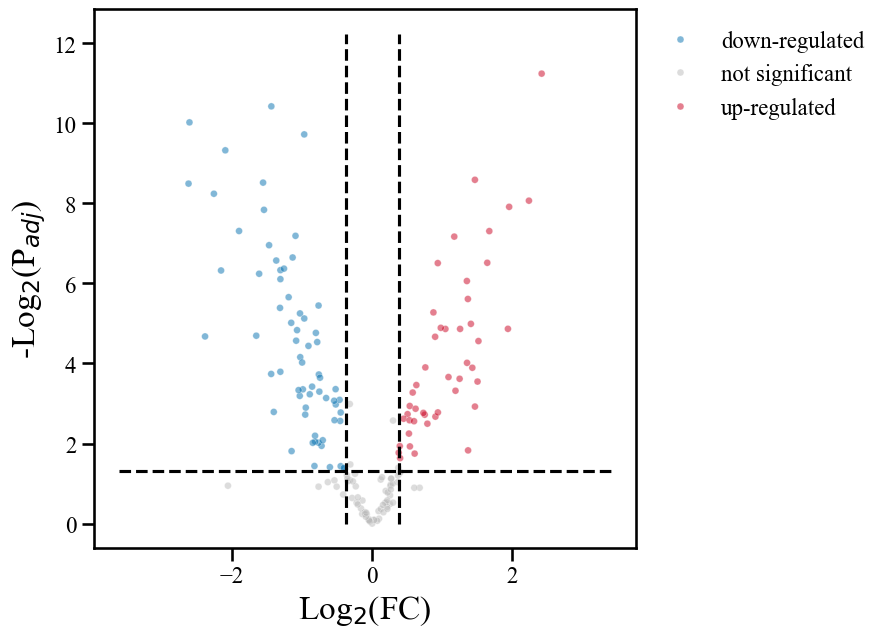

In [87]:
volcano_plot(dataset)

In [88]:
# volcano_plot_annotate(dataset)

In [89]:
# volcano_plot(dataset24h)

### Significant protein slicing. 

In [90]:
# prot_control_vs_low_late_combined_stats_withAnnote.columns

In [91]:
# sig_control_vs_low_late_combined = prot_control_vs_low_late_combined_stats_withAnnote[prot_control_vs_low_late_combined_stats_withAnnote['ANOVA_padj'] < 0.05]
# sig_control_vs_low_24h = prot_control_vs_low_24h_stats_withAnnote[prot_control_vs_low_24h_stats_withAnnote['ANOVA_padj'] < 0.05]

### optional save. 

In [92]:
# sig_control_vs_low_late_combined.to_csv('Sig_control_vs_low_late_combined.csv')
# sig_control_vs_low_24h.to_csv('Sig_control_vs_low_24h.csv')

## Compare Control vs Oscillation.  

In [93]:
prot = annotated_phospho[sample_ids_prot_redox]
prot['Protein'] = annotated_phospho['Site']
prot.index = annotated_phospho['Site']
# drop oscillations.
# prot_control_vs_oscillation_24h = prot.drop(prot.columns[prot.columns.str.contains("Low")], axis=1)
prot_control_vs_oscillation_late_combined = prot.drop(prot.columns[prot.columns.str.contains("Low")], axis=1)


# drop early timepoints. 
# prot_control_vs_oscillation_24h = prot_control_vs_oscillation_24h.drop(prot_control_vs_oscillation_24h.columns[
#     prot_control_vs_oscillation_24h.columns.str.contains("5.5|3.5|4.5|48|72")], axis=1)

prot_control_vs_oscillation_late_combined = prot_control_vs_oscillation_late_combined.drop(prot_control_vs_oscillation_late_combined.columns[
    prot_control_vs_oscillation_late_combined.columns.str.contains("5.5|3.5|4.5")], axis=1)



 

/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1265878771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot['Protein'] = annotated_phospho['Site']


In [94]:
prot_condition_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['condition']))
prot_timepoint_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['timepoint']))

### Prep for p-values. 

In [95]:
# group for mapping in nanova. 


condition_series_controlvsOscLateCombined = pd.Series(prot_control_vs_oscillation_late_combined.columns).map(prot_condition_dict)
condition_series_controlvsOscLateCombined.index = prot_control_vs_oscillation_late_combined.columns
condition_series_controlvsOscLateCombined 

# condition_series_controlvsOsc24 = pd.Series(prot_control_vs_oscillation_24h.columns).map(prot_condition_dict)
# condition_series_controlvsOsc24.index = prot_control_vs_oscillation_24h.columns
# condition_series_controlvsOsc24 


Biostat2L_29_Oscillation_24    Oscillation
Biostat2L_29_Oscillation_48    Oscillation
Biostat2L_29_Oscillation_72    Oscillation
Biostat2L_30_Control_24            Control
Biostat2L_30_Control_48            Control
Biostat2L_30_Control_72            Control
Biostat2L_30_Oscillation_24    Oscillation
Biostat2L_30_Oscillation_48    Oscillation
Biostat2L_30_Oscillation_72    Oscillation
Biostat2L_31_Control_24            Control
Biostat2L_31_Control_48            Control
Biostat2L_31_Control_72            Control
Biostat2L_31_Oscillation_24    Oscillation
Biostat2L_31_Oscillation_48    Oscillation
Biostat2L_31_Oscillation_72    Oscillation
Biostat2L_32_Control_24            Control
Biostat2L_32_Control_48            Control
Biostat2L_32_Control_72            Control
Protein                                NaN
dtype: object

In [96]:
# late stats.
prot_control_vs_oscillation_late_combined_stats = global_stats_calc_prot(prot_control_vs_oscillation_late_combined,
                                                                         condition_series_controlvsOscLateCombined )

# 24 h stats. 
# prot_control_vs_oscillation_24h_stats = global_stats_calc_prot(prot_control_vs_oscillation_24h,
                                                                  # condition_series_controlvsOsc24)


In [97]:
# Extract the number between "YarliW29_1|" and "@GLB" using regex.
prot_control_vs_oscillation_late_combined_stats["proteinID"] = prot_control_vs_oscillation_late_combined_stats["Site"].str.extract(r"YarliW29_1\|(\d+)@")
# prot_control_vs_oscillation_24h_stats["proteinID"] = prot_control_vs_oscillation_24h_stats["Protein"].str.extract(r"YarliW29_1\|(\d+)@GLB")



# Convert the extracted number to integer (if needed).
prot_control_vs_oscillation_late_combined_stats["proteinID"] = prot_control_vs_oscillation_late_combined_stats["proteinID"].astype(int)
# prot_control_vs_oscillation_24h_stats["proteinID"] = prot_control_vs_oscillation_24h_stats["proteinID"].astype(int)


### calculate log2FC

In [98]:
controlLateCombined = prot_control_vs_oscillation_late_combined_stats.loc[:, prot_control_vs_oscillation_late_combined_stats.columns[prot_control_vs_oscillation_late_combined_stats.columns.str.contains("Control")]]
# control24h = prot_control_vs_oscillation_24h_stats.loc[:, prot_control_vs_oscillation_24h_stats.columns[prot_control_vs_oscillation_24h_stats.columns.str.contains("Control")]]
# control24h.head()


In [99]:
oscLateCombinedLate = prot_control_vs_oscillation_late_combined_stats.loc[:, prot_control_vs_oscillation_late_combined_stats.columns[
    prot_control_vs_oscillation_late_combined_stats.columns.str.contains("Oscillation")]]

# osc24h = prot_control_vs_oscillation_24h_stats.loc[:, prot_control_vs_oscillation_24h_stats.columns[
    # prot_control_vs_oscillation_24h_stats.columns.str.contains("Oscillation")]]
# osc24h.head()

In [100]:
oscLateCombinedLate.head()

,Biostat2L_29_Oscillation_24,Biostat2L_29_Oscillation_48,Biostat2L_29_Oscillation_72,Biostat2L_30_Oscillation_24,Biostat2L_30_Oscillation_48,Biostat2L_30_Oscillation_72,Biostat2L_31_Oscillation_24,Biostat2L_31_Oscillation_48,Biostat2L_31_Oscillation_72
0,13.921812,14.148031,13.556648,13.728869,13.957324,14.072943,13.943018,13.816518,14.655760
1,14.687903,14.764124,14.143469,14.749323,14.903341,14.317786,15.112586,15.277582,15.195779
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18.450295,19.224261,19.409963,18.449405,19.105002,19.042270,18.343261,19.083977,19.094777
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
# gives the increase of the first. 
# prot_control_vs_oscillation_24h_stats['log2FC']=log2FC_function(osc24h, control24h)
prot_control_vs_oscillation_late_combined_stats['log2FC']=log2FC_function(oscLateCombinedLate,controlLateCombined)


In [102]:
df_to_merge = pd.DataFrame()
df_to_merge['osc/control_late_cominbed'] = prot_control_vs_oscillation_late_combined_stats['log2FC']
df_to_merge['Site'] = prot_control_vs_oscillation_late_combined_stats['Site']
df_to_merge['osc/control_late_cominbedANOVA_padj'] = prot_control_vs_oscillation_late_combined_stats['ANOVA_padj']
df_to_merge['osc/control_late_cominbedANOVA_p'] = prot_control_vs_oscillation_late_combined_stats['ANOVA_p']



In [103]:
merged_df = pd.merge(merged_df, df_to_merge, left_on='Site',right_on='Site', how='left')

In [104]:
merged_df.head(20)

,Peptide,Site,UniProt,Protein,Residue,AScore,id,Total missingness,Oscillation_24 missingness,Oscillation_3.5 missingness,...,kogGroup,early/late,early/late_ANOVA_padj,early/late_ANOVA_p,low/control_late_combined,low/control_late_combined_ANOVA_padj,low/control_late_combined_ANOVA_p,osc/control_late_cominbed,osc/control_late_cominbedANOVA_padj,osc/control_late_cominbedANOVA_p
0,K.LAEENTSEAIFDTPDT#DEDDAK.S,jgi|YarliW29_1|1012@T748,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,T748,43.40600,jgi|YarliW29_1|1012@T748,18,0,0,...,POORLY CHARACTERIZED,-0.856726,4.690131e-05,1.944688e-05,NaN,NaN,NaN,0.325942,6.284987e-02,3.091534e-02
1,R.SNS#MSAFR.M,jgi|YarliW29_1|1029@S1108,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S1108,22.21700,jgi|YarliW29_1|1029@S1108,18,0,0,...,NaN,-0.724107,3.651293e-05,1.457279e-05,NaN,NaN,NaN,-0.190275,2.827569e-01,1.925804e-01
2,R.RGS#MTSTTTNTER.T,jgi|YarliW29_1|1029@S212,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S212,45.54300,jgi|YarliW29_1|1029@S212,36,3,3,...,NaN,-1.081031,1.456955e-05,5.039577e-06,NaN,NaN,NaN,NaN,NaN,NaN
3,R.THS#LTSTTTTIK.R; R.THS#LTSTTTTIKR.M,jgi|YarliW29_1|1029@S225,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S225,28.74600,jgi|YarliW29_1|1029@S225,0,0,0,...,NaN,-1.023307,1.647810e-06,4.347879e-07,0.394520,0.020056,0.011606,-0.234903,2.638042e-01,1.739682e-01
4,R.TLS#PM*KPALK.M; R.TLS#PMKPALK.M,jgi|YarliW29_1|1029@S368,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S368,1000.00000,jgi|YarliW29_1|1029@S368,18,3,3,...,NaN,-0.196793,3.051088e-01,2.611352e-01,-1.030425,0.000030,0.000006,NaN,NaN,NaN
5,R.ANS#GLSSAAAAAAIR.H,jgi|YarliW29_1|1029@S49,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S49,107.28000,jgi|YarliW29_1|1029@S49,5,0,1,...,NaN,-0.656691,6.284172e-05,2.647434e-05,-0.311865,0.054012,0.033378,-0.225629,4.064759e-01,3.098006e-01
6,R.QAAPAPPSQVLSPM*LS#HSESEEDLSMFQDAHEHLGK.S,jgi|YarliW29_1|1029@S559,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S559,23.94200,jgi|YarliW29_1|1029@S559,49,3,3,...,NaN,-0.129958,8.865105e-01,8.609570e-01,NaN,NaN,NaN,NaN,NaN,NaN
7,R.HHS#LTSSTSQPNLQQGR.N,jgi|YarliW29_1|1029@S64,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S64,45.54300,jgi|YarliW29_1|1029@S64,37,3,3,...,NaN,-1.161774,1.456850e-03,8.075666e-04,NaN,NaN,NaN,NaN,NaN,NaN
8,K.T#PGGAAQHFLDDDDYFSR.G,jgi|YarliW29_1|1049@T925,jgi|YarliW29_1|1049,jgi|YarliW29_1|1049,T925,256.78000,jgi|YarliW29_1|1049@T925,1,0,1,...,METABOLISM,-1.337130,1.078196e-03,5.857162e-04,-1.404896,0.003578,0.001628,0.953048,1.872955e-01,1.164270e-01
9,K.LHDVANSPYQSS#PR.T,jgi|YarliW29_1|1051@S540,jgi|YarliW29_1|1051,jgi|YarliW29_1|1051,S540,0.00000,jgi|YarliW29_1|1051@S540,19,3,3,...,CELLULAR PROCESSES AND SIGNALING,-0.705503,4.881143e-03,2.933015e-03,-1.072325,0.000064,0.000015,NaN,NaN,NaN


In [105]:
merged_df

,Peptide,Site,UniProt,Protein,Residue,AScore,id,Total missingness,Oscillation_24 missingness,Oscillation_3.5 missingness,...,kogGroup,early/late,early/late_ANOVA_padj,early/late_ANOVA_p,low/control_late_combined,low/control_late_combined_ANOVA_padj,low/control_late_combined_ANOVA_p,osc/control_late_cominbed,osc/control_late_cominbedANOVA_padj,osc/control_late_cominbedANOVA_p
0,K.LAEENTSEAIFDTPDT#DEDDAK.S,jgi|YarliW29_1|1012@T748,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,T748,43.406,jgi|YarliW29_1|1012@T748,18,0,0,...,POORLY CHARACTERIZED,-0.856726,4.690131e-05,1.944688e-05,NaN,NaN,NaN,0.325942,0.062850,0.030915
1,R.SNS#MSAFR.M,jgi|YarliW29_1|1029@S1108,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S1108,22.217,jgi|YarliW29_1|1029@S1108,18,0,0,...,NaN,-0.724107,3.651293e-05,1.457279e-05,NaN,NaN,NaN,-0.190275,0.282757,0.192580
2,R.RGS#MTSTTTNTER.T,jgi|YarliW29_1|1029@S212,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S212,45.543,jgi|YarliW29_1|1029@S212,36,3,3,...,NaN,-1.081031,1.456955e-05,5.039577e-06,NaN,NaN,NaN,NaN,NaN,NaN
3,R.THS#LTSTTTTIK.R; R.THS#LTSTTTTIKR.M,jgi|YarliW29_1|1029@S225,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S225,28.746,jgi|YarliW29_1|1029@S225,0,0,0,...,NaN,-1.023307,1.647810e-06,4.347879e-07,0.394520,0.020056,0.011606,-0.234903,0.263804,0.173968
4,R.TLS#PM*KPALK.M; R.TLS#PMKPALK.M,jgi|YarliW29_1|1029@S368,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S368,1000.000,jgi|YarliW29_1|1029@S368,18,3,3,...,NaN,-0.196793,3.051088e-01,2.611352e-01,-1.030425,0.000030,0.000006,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,R.SYTDELQDTQVLEDPAES#DEEEEPVISR.K,jgi|YarliW29_1|868@S383,jgi|YarliW29_1|868,jgi|YarliW29_1|868,S383,138.590,jgi|YarliW29_1|868@S383,49,3,3,...,POORLY CHARACTERIZED,-0.296738,4.992397e-01,4.549612e-01,NaN,NaN,NaN,NaN,NaN,NaN
453,R.AAS#PSPVFR.S,jgi|YarliW29_1|930@S188,jgi|YarliW29_1|930,jgi|YarliW29_1|930,S188,39.967,jgi|YarliW29_1|930@S188,36,3,3,...,POORLY CHARACTERIZED,-1.108683,3.996093e-07,8.949123e-08,NaN,NaN,NaN,NaN,NaN,NaN
454,R.SSS#QSNIASIGFGK.W,jgi|YarliW29_1|965@S260,jgi|YarliW29_1|965,jgi|YarliW29_1|965,S260,0.000,jgi|YarliW29_1|965@S260,18,3,3,...,METABOLISM,-1.021961,4.460152e-09,3.757999e-10,-0.244271,0.085368,0.057072,NaN,NaN,NaN
455,K.RS#PEASPEK.R,jgi|YarliW29_1|971@S12,jgi|YarliW29_1|971,jgi|YarliW29_1|971,S12,83.653,jgi|YarliW29_1|971@S12,18,0,0,...,INFORMATION STORAGE AND PROCESSING,-1.277760,3.283456e-07,7.061980e-08,NaN,NaN,NaN,0.287181,0.357872,0.259215


### optional save. This is final file with proteomic details. 

In [106]:
merged_df["proteinId"] = merged_df["Site"].str.extract(r"YarliW29_1\|(\d+)@")
merged_df['proteinID'] = merged_df['proteinId'].copy()
merged_df['#proteinId'] = merged_df['proteinId'].copy()

In [107]:
# merged_df.to_csv('../Data/PPI_yarrowia_REDOX_Global/result/PPI_yarrowia_redox_wAnnotations_fullLog2FC.csv')

In [108]:
prot_control_vs_oscillation_late_combined_stats.head()

,Site,Biostat2L_29_Oscillation_24,Biostat2L_29_Oscillation_48,Biostat2L_29_Oscillation_72,Biostat2L_30_Control_24,Biostat2L_30_Control_48,Biostat2L_30_Control_72,Biostat2L_30_Oscillation_24,Biostat2L_30_Oscillation_48,Biostat2L_30_Oscillation_72,...,Biostat2L_31_Oscillation_48,Biostat2L_31_Oscillation_72,Biostat2L_32_Control_24,Biostat2L_32_Control_48,Biostat2L_32_Control_72,Protein,ANOVA_p,ANOVA_padj,proteinID,log2FC
0,jgi|YarliW29_1|1012@T748,13.921812,14.148031,13.556648,13.787372,14.073101,13.139452,13.728869,13.957324,14.072943,...,13.816518,14.655760,13.571825,13.513770,13.580512,jgi|YarliW29_1|1012@T748,0.030915,0.062850,1012,0.325942
1,jgi|YarliW29_1|1029@S1108,14.687903,14.764124,14.143469,14.986167,15.273361,15.055229,14.749323,14.903341,14.317786,...,15.277582,15.195779,14.785028,14.819879,14.811235,jgi|YarliW29_1|1029@S1108,0.192580,0.282757,1029,-0.190275
2,jgi|YarliW29_1|1029@S212,NaN,NaN,NaN,14.699762,14.329749,14.208659,NaN,NaN,NaN,...,NaN,NaN,13.936396,14.696044,14.338431,jgi|YarliW29_1|1029@S212,NaN,NaN,1029,NaN
3,jgi|YarliW29_1|1029@S225,18.450295,19.224261,19.409963,19.030934,19.312877,19.436340,18.449405,19.105002,19.042270,...,19.083977,19.094777,18.683641,19.453357,19.281014,jgi|YarliW29_1|1029@S225,0.173968,0.263804,1029,-0.234903
4,jgi|YarliW29_1|1029@S368,NaN,NaN,NaN,17.105610,17.644165,17.407525,NaN,NaN,NaN,...,NaN,NaN,16.853587,17.659650,17.554265,jgi|YarliW29_1|1029@S368,NaN,NaN,1029,NaN


In [109]:
prot_control_vs_oscillation_late_combined_stats_withAnnote = pd.merge(prot_control_vs_oscillation_late_combined_stats, 
                                                                      merged_annotations, left_on='proteinID', right_on='#proteinId', how='left')
# prot_control_vs_oscillation_24h_stats_withAnnote = pd.merge(prot_control_vs_oscillation_24h_stats, 
                                                                      # merged_annotations, left_on='proteinID', right_on='#proteinId', how='left')

In [110]:
# prot_control_vs_oscillation_late_combined_stats_withAnnote.to_csv('control_vs_oscillation_late.csv')
# prot_control_vs_oscillation_24h_stats_withAnnote.to_csv('control_vs_oscillation_24h.csv')

### Volcano plot comparing low vs high, 
all late (increase means increased in low)


In [111]:
dataset_late_combined = prot_control_vs_oscillation_late_combined_stats_withAnnote[['log2FC', 'ANOVA_padj']].copy()
# dataset_24h = prot_control_vs_oscillation_24h_stats_withAnnote[['log2FC', 'ANOVA_padj']].copy()

In [113]:
log2FC_threshold = np.log2(1.3)

In [112]:

# subset the log2FC and the P_value for this dataset. 
dataset_late_combined.columns = ['log2FC','P_value']

# obtain the -logP_adj for the dataset. 
dataset_late_combined['-logP_adj'] = -np.log10(dataset_late_combined['P_value'])

# set a class for up (1) or down (-1) proteins. 
dataset_late_combined['class'] = 0
dataset_late_combined.loc[(dataset_late_combined['log2FC']>log2FC_threshold)&(dataset_late_combined['-logP_adj']>-np.log10(0.05)),'class'] = 1
dataset_late_combined.loc[(dataset_late_combined['log2FC']<-log2FC_threshold)&(dataset_late_combined['-logP_adj']>-np.log10(0.05)),'class'] = -1

In [115]:
# # subset the log2FC and the P_value for this dataset. 
# dataset_24h.columns = ['log2FC','P_value']

# # obtain the -logP_adj for the dataset. 
# dataset_24h['-logP_adj'] = -np.log10(dataset_24h['P_value'])

# # set a class for up (1) or down (-1) proteins. 
# dataset_24h['class'] = 0
# dataset_24h.loc[(dataset_24h['log2FC']>log2FC_threshold)&(dataset_24h['-logP_adj']>-np.log10(0.05)),'class'] = 1
# dataset_24h.loc[(dataset_24h['log2FC']<-log2FC_threshold)&(dataset_24h['-logP_adj']>-np.log10(0.05)),'class'] = -1

/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:202: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_min = df.min()[0]-1
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:203: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_max = df.max()[0]+1
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:206: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_

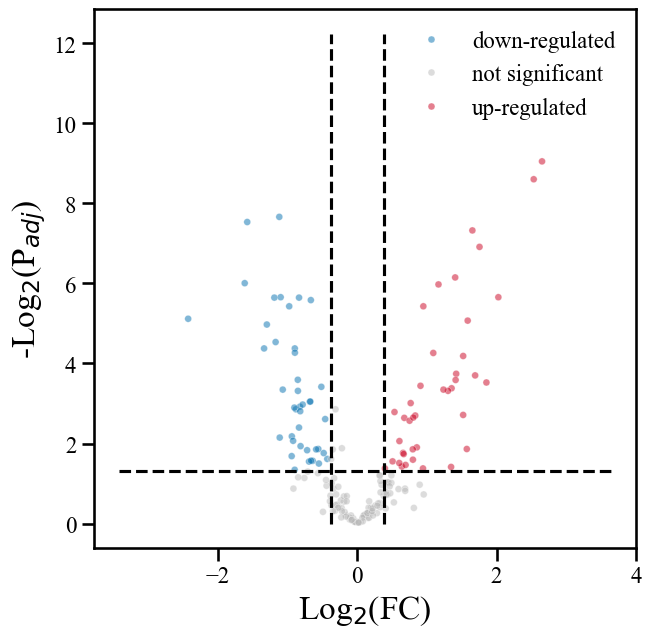

In [113]:
volcano_plot(dataset_late_combined)

In [117]:
# volcano_plot(dataset_24h)

## Compare Oscillation vs Low. Start with all late.

### prep for p-values.

In [114]:
prot = annotated_phospho[sample_ids_prot_redox]
prot['Protein'] = annotated_phospho['Site']
prot.index = annotated_phospho['Site']
# drop oscillations.
# prot_control_vs_oscillation_24h = prot.drop(prot.columns[prot.columns.str.contains("Low")], axis=1)
prot_oscillation_vs_low_late_combined = prot.drop(prot.columns[prot.columns.str.contains("Control")], axis=1)


# drop early timepoints. 
prot_oscillation_vs_low_late_combined = prot_oscillation_vs_low_late_combined.drop(prot_oscillation_vs_low_late_combined.columns[
    prot_oscillation_vs_low_late_combined.columns.str.contains("5.5|3.5|4.5")], axis=1)



 

/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/3842424781.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot['Protein'] = annotated_phospho['Site']


In [115]:
prot_condition_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['condition']))
prot_timepoint_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['timepoint']))

In [116]:
# group for mapping in annova. 

condition_series_OscvsLowLateCombined = pd.Series(prot_oscillation_vs_low_late_combined.columns).map(prot_condition_dict)
condition_series_OscvsLowLateCombined.index = prot_oscillation_vs_low_late_combined.columns
condition_series_OscvsLowLateCombined 



Biostat2L_29_Oscillation_24    Oscillation
Biostat2L_29_Oscillation_48    Oscillation
Biostat2L_29_Oscillation_72    Oscillation
Biostat2L_30_Oscillation_24    Oscillation
Biostat2L_30_Oscillation_48    Oscillation
Biostat2L_30_Oscillation_72    Oscillation
Biostat2L_31_Oscillation_24    Oscillation
Biostat2L_31_Oscillation_48    Oscillation
Biostat2L_31_Oscillation_72    Oscillation
Biostat2L_32_Low_24                    Low
Biostat2L_32_Low_48                    Low
Biostat2L_32_Low_72                    Low
Biostat2L_33_Low_24                    Low
Biostat2L_33_Low_48                    Low
Biostat2L_33_Low_72                    Low
Biostat2L_34_Low_24                    Low
Biostat2L_34_Low_48                    Low
Biostat2L_34_Low_72                    Low
Protein                                NaN
dtype: object

In [117]:
# late stats.
prot_OscvsLowLateCombined_stats = global_stats_calc_prot(prot_oscillation_vs_low_late_combined,
                                                                         condition_series_OscvsLowLateCombined)




/Users/czaj603/miniconda3/envs/bio/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:580: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_86620/1246007795.py:141: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = f_oneway(*group_data)


In [118]:
# Extract the number between "YarliW29_1|" and "@GLB" using regex.
prot_OscvsLowLateCombined_stats["proteinID"] = prot_OscvsLowLateCombined_stats["Site"].str.extract(r"YarliW29_1\|(\d+)@")



# Convert the extracted number to integer (if needed).
prot_OscvsLowLateCombined_stats["proteinID"] = prot_OscvsLowLateCombined_stats["proteinID"].astype(int)


### calculate log2FC

In [119]:
oscLateCombinedLate = prot_OscvsLowLateCombined_stats.loc[:, prot_OscvsLowLateCombined_stats.columns[
    prot_OscvsLowLateCombined_stats.columns.str.contains("Oscillation")]]


oscLateCombinedLate.head()

,Biostat2L_29_Oscillation_24,Biostat2L_29_Oscillation_48,Biostat2L_29_Oscillation_72,Biostat2L_30_Oscillation_24,Biostat2L_30_Oscillation_48,Biostat2L_30_Oscillation_72,Biostat2L_31_Oscillation_24,Biostat2L_31_Oscillation_48,Biostat2L_31_Oscillation_72
0,13.921812,14.148031,13.556648,13.728869,13.957324,14.072943,13.943018,13.816518,14.655760
1,14.687903,14.764124,14.143469,14.749323,14.903341,14.317786,15.112586,15.277582,15.195779
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18.450295,19.224261,19.409963,18.449405,19.105002,19.042270,18.343261,19.083977,19.094777
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
lowLateCombined = prot_OscvsLowLateCombined_stats.loc[:, prot_OscvsLowLateCombined_stats.columns[prot_OscvsLowLateCombined_stats.columns.str.contains("Low")]]
lowLateCombined.head()


,Biostat2L_32_Low_24,Biostat2L_32_Low_48,Biostat2L_32_Low_72,Biostat2L_33_Low_24,Biostat2L_33_Low_48,Biostat2L_33_Low_72,Biostat2L_34_Low_24,Biostat2L_34_Low_48,Biostat2L_34_Low_72
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,19.143275,19.618330,19.928461,19.560714,19.514274,19.683966,19.120369,19.430804,19.867831
4,16.613736,16.329088,16.183309,16.512579,16.373739,15.780137,17.059593,16.416683,16.037147


In [121]:
# gives the increase of the first. 
prot_OscvsLowLateCombined_stats['log2FC_Osc_vs_low_Late']=log2FC_function(oscLateCombinedLate, lowLateCombined)


In [122]:
df_to_merge = pd.DataFrame()
df_to_merge['osc/low_late_cominbed'] = prot_OscvsLowLateCombined_stats['log2FC_Osc_vs_low_Late']
df_to_merge['Site'] = prot_OscvsLowLateCombined_stats['Site']
# df_to_merge['osc/low_late_cominbedANOVA_padj'] = prot_OscvsLowLateCombined_stats['ANOVA_padj']
df_to_merge['osc/low_late_cominbedANOVA_p'] = prot_OscvsLowLateCombined_stats['ANOVA_p']



In [123]:
merged_df = pd.merge(merged_df, df_to_merge, left_on='Site',right_on='Site', how='left')

# multiple Yarrowia gene annotations. mapping/annotations

In [124]:
prot_control_late_vs_early_combined_stats_withAnnote['ANOVA_padj']=pd.Series(np.nan)
prot_control_vs_low_late_combined_stats_withAnnote['ANOVA_padj']=pd.Series(np.nan)
prot_control_vs_oscillation_late_combined_stats_withAnnote['ANOVA_padj']=pd.Series(np.nan)

In [125]:
combined_df = merged_df.copy()

In [126]:
combined_df['proteinId'] = combined_df['proteinID'].copy()

In [127]:
combined_df['#proteinId'] = combined_df['proteinID'].copy()

In [128]:
gene_dict = {}

# Step Open and Read the FASTA File
with open('../Data/DNA/W29.fasta', 'r') as fasta_file:
    for line in fasta_file:
        # Check for header lines starting with ">"
        if line.startswith(">"):
            # Extract the relevant fields from the header line
            header_parts = line.strip().split('|')  # Split header by '|'
            gene_id = header_parts[2]  # "1000"
            gene_name = header_parts[3]  # "YALI1_B02228p"
            
            # Map "1000" to "YALI1_B02228p" in the dictionary
            gene_dict[gene_id] = gene_name

In [129]:
gene_dict

{'1000': 'YALI1_B02228p',
 '1001': 'YALI1_B02283p',
 '1002': 'YALI1_B02345p',
 '1003': 'YALI1_B02375p',
 '1004': 'YALI1_B02415p',
 '1005': 'YALI1_B02430p',
 '1006': 'YALI1_B02465p',
 '1007': 'YALI1_B02472p',
 '1008': 'YALI1_B02487p',
 '1009': 'YALI1_B02496p',
 '100': 'YALI1_A02775p',
 '1010': 'YALI1_B02506p',
 '1011': 'YALI1_B02533p',
 '1012': 'YALI1_B02550p',
 '1013': 'YALI1_B02604p',
 '1014': 'YALI1_B02637p',
 '1015': 'YALI1_B02642p',
 '1016': 'YALI1_B02672p',
 '1017': 'YALI1_B02696p',
 '1018': 'YALI1_B02717p',
 '1019': 'YALI1_B02733p',
 '101': 'YALI1_A02813p',
 '1020': 'YALI1_B02767p',
 '1021': 'YALI1_B02781p',
 '1022': 'YALI1_B02806p',
 '1023': 'YALI1_B02833p',
 '1024': 'YALI1_B02850p',
 '1025': 'YALI1_B02874p',
 '1026': 'YALI1_B02881p',
 '1027': 'YALI1_B02910p',
 '1028': 'YALI1_B02931p',
 '1029': 'YALI1_B02991p',
 '102': 'YALI1_A02819p',
 '1030': 'YALI1_B03021p',
 '1031': 'YALI1_B03041p',
 '1032': 'YALI1_B03043p',
 '1033': 'YALI1_B03085p',
 '1034': 'YALI1_B03120p',
 '1035': 'YALI1

In [130]:
combined_df['YALI1_protID'] = combined_df['proteinID'].map(gene_dict)
combined_df['YALI1_mod'] = combined_df['YALI1_protID'].str.replace('p', 'g', regex=False)

In [131]:
combined_df.head()

,Peptide,Site,UniProt,Protein,Residue,AScore,id,Total missingness,Oscillation_24 missingness,Oscillation_3.5 missingness,...,low/control_late_combined,low/control_late_combined_ANOVA_padj,low/control_late_combined_ANOVA_p,osc/control_late_cominbed,osc/control_late_cominbedANOVA_padj,osc/control_late_cominbedANOVA_p,proteinID,#proteinId,osc/low_late_cominbed,osc/low_late_cominbedANOVA_p
0,K.LAEENTSEAIFDTPDT#DEDDAK.S,jgi|YarliW29_1|1012@T748,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,T748,43.406,jgi|YarliW29_1|1012@T748,18,0,0,...,NaN,NaN,NaN,0.325942,0.062850,0.030915,1012,1012,NaN,NaN
1,R.SNS#MSAFR.M,jgi|YarliW29_1|1029@S1108,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S1108,22.217,jgi|YarliW29_1|1029@S1108,18,0,0,...,NaN,NaN,NaN,-0.190275,0.282757,0.192580,1029,1029,NaN,NaN
2,R.RGS#MTSTTTNTER.T,jgi|YarliW29_1|1029@S212,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S212,45.543,jgi|YarliW29_1|1029@S212,36,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,1029,1029,NaN,NaN
3,R.THS#LTSTTTTIK.R; R.THS#LTSTTTTIKR.M,jgi|YarliW29_1|1029@S225,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S225,28.746,jgi|YarliW29_1|1029@S225,0,0,0,...,0.394520,0.020056,0.011606,-0.234903,0.263804,0.173968,1029,1029,-0.629424,0.001191
4,R.TLS#PM*KPALK.M; R.TLS#PMKPALK.M,jgi|YarliW29_1|1029@S368,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S368,1000.000,jgi|YarliW29_1|1029@S368,18,3,3,...,-1.030425,0.000030,0.000006,NaN,NaN,NaN,1029,1029,NaN,NaN


In [132]:
# File path to your GFF file
gff_file = "../Data/DNA/genomic_yali1_yali2.gff"

# Initialize mapping dictionary
yali1_to_yali2 = {}

# Regex patterns for locus_tag and old_locus_tag
locus_re = re.compile(r'locus_tag=(YALI1_[A-Z0-9]+g)')
old_locus_re = re.compile(r'old_locus_tag=(YALI2_[A-Z0-9]+g)')

# Parse the GFF
with open(gff_file, 'r') as file:
    for line in file:
        if line.startswith("#"):
            continue
        if "\tgene\t" not in line:
            continue

        locus_match = locus_re.search(line)
        old_locus_match = old_locus_re.search(line)

        if locus_match and old_locus_match:
            yali1 = locus_match.group(1)
            yali2 = old_locus_match.group(1)
            yali1_to_yali2[yali1] = yali2

# Convert to DataFrame for inspection or export
df_map = pd.DataFrame(list(yali1_to_yali2.items()), columns=["YALI1", "YALI2"])

# Optionally save to CSV
df_map.to_csv("yali1_to_yali2_mapping.csv", index=False)



In [133]:
df_map['YALI1'] = df_map['YALI1'].str.replace('g', 'p', regex=False)
locus_dict_2 = dict(zip(df_map["YALI1"], df_map["YALI2"]))


In [134]:
df_map

,YALI1,YALI2
0,YALI1_A00058p,YALI2_A00002g
1,YALI1_A00102p,YALI2_A00003g
2,YALI1_A00148p,YALI2_A00004g
3,YALI1_A00204p,YALI2_A00005g
4,YALI1_A00241p,YALI2_A00692g
...,...,...
6210,YALI1_F39665p,YALI2_E00867g
6211,YALI1_F39789p,YALI2_E00868g
6212,YALI1_F39844p,YALI2_E00869g
6213,YALI1_F39885p,YALI2_E00871g


In [135]:
combined_df['YALI2'] = combined_df['YALI1_protID'].map(df_map.set_index('YALI1')['YALI2'])

In [136]:
combined_df.head()

,Peptide,Site,UniProt,Protein,Residue,AScore,id,Total missingness,Oscillation_24 missingness,Oscillation_3.5 missingness,...,low/control_late_combined,low/control_late_combined_ANOVA_padj,low/control_late_combined_ANOVA_p,osc/control_late_cominbed,osc/control_late_cominbedANOVA_padj,osc/control_late_cominbedANOVA_p,proteinID,#proteinId,osc/low_late_cominbed,osc/low_late_cominbedANOVA_p
0,K.LAEENTSEAIFDTPDT#DEDDAK.S,jgi|YarliW29_1|1012@T748,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,T748,43.406,jgi|YarliW29_1|1012@T748,18,0,0,...,NaN,NaN,NaN,0.325942,0.062850,0.030915,1012,1012,NaN,NaN
1,R.SNS#MSAFR.M,jgi|YarliW29_1|1029@S1108,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S1108,22.217,jgi|YarliW29_1|1029@S1108,18,0,0,...,NaN,NaN,NaN,-0.190275,0.282757,0.192580,1029,1029,NaN,NaN
2,R.RGS#MTSTTTNTER.T,jgi|YarliW29_1|1029@S212,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S212,45.543,jgi|YarliW29_1|1029@S212,36,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,1029,1029,NaN,NaN
3,R.THS#LTSTTTTIK.R; R.THS#LTSTTTTIKR.M,jgi|YarliW29_1|1029@S225,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S225,28.746,jgi|YarliW29_1|1029@S225,0,0,0,...,0.394520,0.020056,0.011606,-0.234903,0.263804,0.173968,1029,1029,-0.629424,0.001191
4,R.TLS#PM*KPALK.M; R.TLS#PMKPALK.M,jgi|YarliW29_1|1029@S368,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S368,1000.000,jgi|YarliW29_1|1029@S368,18,3,3,...,-1.030425,0.000030,0.000006,NaN,NaN,NaN,1029,1029,NaN,NaN


In [137]:
# JGI_protID_toYali1 = pd.DataFrame(list(gene_dict.items()), columns=['JGI_protID', 'YALI1_protID'])
# # JGI_protID_toYali1.to_csv('JGI_Yali1_protMap.csv')
# JGI_protID_toYali1.head()

In [138]:
df = pd.read_excel('../Annotations/yali_genes.xlsx')
df.head()
# df = pd.read_excel('../Data/locus_tag_map.xlsx')
# df.head()

,YALI0 locus ID,YALI1 Locus ID,YALI1 Proteins,Gene Type,Chromosome,Start Base,End Base,Strand,Annotation
0,NaN,YALI1_A00014g,YALI1_A00014p,mRNA,YALI1A,1230,1648,-,NaN
1,NaN,YALI1_A00019g,YALI1_A00019p,mRNA,YALI1A,1806,2173,-,NaN
2,NaN,YALI1_A00032g,YALI1_A00032p,mRNA,YALI1A,3285,3920,+,NaN
3,YALI0A00110g,YALI1_A00058g,YALI1_A00058p,mRNA,YALI1A,5913,8531,+,weakly similar to uniprot|Q06593 Saccharomyc...
4,YALI0A00132g,YALI1_A00102g,YALI1_A00102p,mRNA,YALI1A,10299,12134,+,highly similar to uniprot|P40150 Saccharomyc...


In [139]:
filtered_df = df.dropna(subset=["YALI0 locus ID"])

locus_dict = dict(zip(filtered_df["YALI1 Proteins"], filtered_df["YALI0 locus ID"]))


In [140]:
combined_df['YALI0_locus'] = combined_df['YALI1_protID'].map(locus_dict)


In [141]:
combined_df.head()

,Peptide,Site,UniProt,Protein,Residue,AScore,id,Total missingness,Oscillation_24 missingness,Oscillation_3.5 missingness,...,low/control_late_combined,low/control_late_combined_ANOVA_padj,low/control_late_combined_ANOVA_p,osc/control_late_cominbed,osc/control_late_cominbedANOVA_padj,osc/control_late_cominbedANOVA_p,proteinID,#proteinId,osc/low_late_cominbed,osc/low_late_cominbedANOVA_p
0,K.LAEENTSEAIFDTPDT#DEDDAK.S,jgi|YarliW29_1|1012@T748,jgi|YarliW29_1|1012,jgi|YarliW29_1|1012,T748,43.406,jgi|YarliW29_1|1012@T748,18,0,0,...,NaN,NaN,NaN,0.325942,0.062850,0.030915,1012,1012,NaN,NaN
1,R.SNS#MSAFR.M,jgi|YarliW29_1|1029@S1108,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S1108,22.217,jgi|YarliW29_1|1029@S1108,18,0,0,...,NaN,NaN,NaN,-0.190275,0.282757,0.192580,1029,1029,NaN,NaN
2,R.RGS#MTSTTTNTER.T,jgi|YarliW29_1|1029@S212,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S212,45.543,jgi|YarliW29_1|1029@S212,36,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,1029,1029,NaN,NaN
3,R.THS#LTSTTTTIK.R; R.THS#LTSTTTTIKR.M,jgi|YarliW29_1|1029@S225,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S225,28.746,jgi|YarliW29_1|1029@S225,0,0,0,...,0.394520,0.020056,0.011606,-0.234903,0.263804,0.173968,1029,1029,-0.629424,0.001191
4,R.TLS#PM*KPALK.M; R.TLS#PMKPALK.M,jgi|YarliW29_1|1029@S368,jgi|YarliW29_1|1029,jgi|YarliW29_1|1029,S368,1000.000,jgi|YarliW29_1|1029@S368,18,3,3,...,-1.030425,0.000030,0.000006,NaN,NaN,NaN,1029,1029,NaN,NaN


## add rest of proteomic comparisions to timepoint. 

In [146]:
# ============================================================
# CONDITION-TO-CONDITION COMPARISONS AT EACH TIMEPOINT
# Adds log2FC, ANOVA_p, and ANOVA_padj directly to combined_df
# ============================================================

# Build protein dataframe exactly as elsewhere in notebook
prot = annotated_phospho[sample_ids_prot_redox]
prot['Protein'] = annotated_phospho['Site']
prot.index = annotated_phospho['Site']

prot_condition_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['condition']))
prot_timepoint_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['timepoint']))


STRESS_VS_CTRL_COLS = [
    "Low_3.5/Control_3.5",
    "Low_4.5/Control_4.5",
    "Low_5.5/Control_5.5",
    "Low_24/Control_24",
    "Low_48/Control_48",
    "Low_72/Control_72",

    "Oscillation_3.5/Control_3.5",
    "Oscillation_4.5/Control_4.5",
    "Oscillation_5.5/Control_5.5",
    "Oscillation_24/Control_24",
    "Oscillation_48/Control_48",
    "Oscillation_72/Control_72",
]


for comparison in STRESS_VS_CTRL_COLS:

    first, second = comparison.split("/")

    first_condition, first_timepoint = first.rsplit("_", 1)
    second_condition, second_timepoint = second.rsplit("_", 1)

    # -------------------------------------------------------
    # Keep only the two conditions being compared
    # -------------------------------------------------------
    prot_compare = prot.drop(
        prot.columns[
            ~(prot.columns.str.contains(first_condition) |
              prot.columns.str.contains(second_condition))
        ],
        axis=1
    )

    # -------------------------------------------------------
    # Keep only the requested timepoint
    # -------------------------------------------------------
    prot_compare = prot_compare.drop(
        prot_compare.columns[
            ~prot_compare.columns.str.contains(f"_{first_timepoint}$")
        ],
        axis=1
    )

    # -------------------------------------------------------
    # Group samples by CONDITION for ANOVA
    # -------------------------------------------------------
    condition_series = pd.Series(
        prot_compare.columns
    ).map(prot_condition_dict)

    condition_series.index = prot_compare.columns

    # -------------------------------------------------------
    # Calculate p-values
    # -------------------------------------------------------
    prot_compare_stats = global_stats_calc_prot(
        prot_compare,
        condition_series
    )

    # -------------------------------------------------------
    # Extract protein ID exactly as elsewhere in notebook
    # -------------------------------------------------------
    prot_compare_stats["proteinID"] = (
        prot_compare_stats["Site"]
        .str.extract(r"YarliW29_1\|(\d+)@")
    )

    prot_compare_stats["proteinID"] = (
        prot_compare_stats["proteinID"].astype(int)
    )

    # -------------------------------------------------------
    # Separate first and second condition
    # -------------------------------------------------------
    first_group = prot_compare_stats[
        prot_compare_stats.columns[
            prot_compare_stats.columns.str.contains(
                f"_{first_condition}_{first_timepoint}$"
            )
        ]
    ]

    second_group = prot_compare_stats[
        prot_compare_stats.columns[
            prot_compare_stats.columns.str.contains(
                f"_{second_condition}_{second_timepoint}$"
            )
        ]
    ]

    # gives the increase of the first
    prot_compare_stats['log2FC'] = log2FC_function(
        first_group,
        second_group
    )

    # -------------------------------------------------------
    # Merge exactly like existing notebook
    # -------------------------------------------------------
    df_to_merge2 = pd.DataFrame()

    df_to_merge2[comparison] = prot_compare_stats['log2FC']
    df_to_merge2['Site'] = prot_compare_stats['Site']
    df_to_merge2[f'{comparison}_ANOVA_padj'] = prot_compare_stats['ANOVA_padj']
    df_to_merge2[f'{comparison}_ANOVA_p'] = prot_compare_stats['ANOVA_p']

    # match proteinId dtype before merge
    # df_to_merge2['proteinID'] = df_to_merge['proteinID'].astype(str)
    # combined_df['proteinId'] = combined_df['proteinId'].astype(str)

    combined_df = pd.merge(
        combined_df,
        df_to_merge2,
        left_on='Site',
        right_on='Site',
        how='left'
    )

/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_76171/1717727680.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot['Protein'] = annotated_phospho['Site']
/Users/czaj603/miniconda3/envs/bio/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:580: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_76171/623302700.py:137: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = f_oneway(*group_data)
/Users/czaj603/miniconda3/envs/bio/lib/python3.11/site-packages/scipy

In [147]:
# Build protein dataframe exactly as elsewhere in notebook
# Build protein dataframe exactly as elsewhere in notebook
prot = annotated_phospho[sample_ids_prot_redox]
prot['Protein'] = annotated_phospho['Site']
prot.index = annotated_phospho['Site']

prot_condition_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['condition']))
prot_timepoint_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['timepoint']))


WITHIN_COND_COLS = [
    "Control_4.5/Control_3.5",
    "Control_5.5/Control_3.5",
    "Control_24/Control_3.5",
    "Control_48/Control_3.5",
    "Control_72/Control_3.5",
    
    "Low_4.5/Low_3.5",
    "Low_5.5/Low_3.5",
    "Low_24/Low_3.5",
    "Low_48/Low_3.5",
    "Low_72/Low_3.5",
    
    "Oscillation_4.5/Oscillation_3.5",
    "Oscillation_5.5/Oscillation_3.5",
    "Oscillation_24/Oscillation_3.5",
    "Oscillation_48/Oscillation_3.5",
    "Oscillation_72/Oscillation_3.5",
]


for comparison in WITHIN_COND_COLS:

    first, second = comparison.split("/")
    
    condition = first.rsplit("_", 1)[0]
    timepoint = first.rsplit("_", 1)[1]

    # -------------------------------------------------------
    # Keep only the condition being tested
    # -------------------------------------------------------
    prot_compare = prot.drop(
        prot.columns[~prot.columns.str.contains(condition)],
        axis=1
    )

    # -------------------------------------------------------
    # Keep only current timepoint and 3.5 h
    # -------------------------------------------------------
    keep_pattern = f"_{timepoint}$|_3.5$"

    prot_compare = prot_compare.drop(
        prot_compare.columns[
            ~prot_compare.columns.str.contains(keep_pattern)
        ],
        axis=1
    )

    # -------------------------------------------------------
    # Group samples by TIMEPOINT for ANOVA
    # -------------------------------------------------------
    timepoint_series = pd.Series(
        prot_compare.columns
    ).map(prot_timepoint_dict)

    timepoint_series.index = prot_compare.columns

    # -------------------------------------------------------
    # Calculate p-values
    # -------------------------------------------------------
    prot_compare_stats = global_stats_calc_prot(
        prot_compare,
        timepoint_series
    )

    # -------------------------------------------------------
    # Extract protein ID exactly as elsewhere in notebook
    # -------------------------------------------------------
    prot_compare_stats["proteinID"] = (
        prot_compare_stats["Site"]
        .str.extract(r"YarliW29_1\|(\d+)@")
    )

    prot_compare_stats["proteinID"] = (
        prot_compare_stats["proteinID"].astype(int)
    )

    # -------------------------------------------------------
    # Separate later timepoint and 3.5 h
    # -------------------------------------------------------
    later = prot_compare_stats[
        prot_compare_stats.columns[
            prot_compare_stats.columns.str.contains(
                f"_{condition}_{timepoint}$"
            )
        ]
    ]

    baseline = prot_compare_stats[
        prot_compare_stats.columns[
            prot_compare_stats.columns.str.contains(
                f"_{condition}_3.5$"
            )
        ]
    ]

    # gives the increase of the first
    prot_compare_stats['log2FC'] = log2FC_function(
        later,
        baseline
    )

    # -------------------------------------------------------
    # Merge exactly like existing notebook
    # -------------------------------------------------------
    df_to_merge2 = pd.DataFrame()

    df_to_merge2[comparison] = prot_compare_stats['log2FC']
    df_to_merge2['Site'] = prot_compare_stats['Site']
    df_to_merge2[f'{comparison}_ANOVA_padj'] = prot_compare_stats['ANOVA_padj']
    df_to_merge2[f'{comparison}_ANOVA_p'] = prot_compare_stats['ANOVA_p']

    # df_to_merge2['Site'] = df_to_merge2['Site'].astype(str)

    combined_df = pd.merge(
        combined_df,
        df_to_merge2,
        left_on='Site',
        right_on='Site',
        how='left'
    )

/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_76171/801847093.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot['Protein'] = annotated_phospho['Site']
/Users/czaj603/miniconda3/envs/bio/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:580: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_76171/623302700.py:137: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = f_oneway(*group_data)
/Users/czaj603/miniconda3/envs/bio/lib/python3.11/site-packages/scipy/

In [148]:
for col in combined_df.columns:
    print(col)

Peptide
Site
UniProt
Protein
Residue
AScore
id
Total missingness
Oscillation_24 missingness
Oscillation_3.5 missingness
Oscillation_4.5 missingness
Oscillation_48 missingness
Oscillation_5.5 missingness
Oscillation_72 missingness
Control_24 missingness
Control_3.5 missingness
Control_4.5 missingness
Control_48 missingness
Control_5.5 missingness
Control_72 missingness
Low_24 missingness
Low_3.5 missingness
Low_4.5 missingness
Low_48 missingness
Low_5.5 missingness
Low_72 missingness
missing_check
Biostat2L_29_Oscillation_24
Biostat2L_29_Oscillation_3.5
Biostat2L_29_Oscillation_4.5
Biostat2L_29_Oscillation_48
Biostat2L_29_Oscillation_5.5
Biostat2L_29_Oscillation_72
Biostat2L_30_Control_24
Biostat2L_30_Control_3.5
Biostat2L_30_Control_4.5
Biostat2L_30_Control_48
Biostat2L_30_Control_5.5
Biostat2L_30_Control_72
Biostat2L_30_Oscillation_24
Biostat2L_30_Oscillation_3.5
Biostat2L_30_Oscillation_4.5
Biostat2L_30_Oscillation_48
Biostat2L_30_Oscillation_5.5
Biostat2L_30_Oscillation_72
Biostat2L

In [142]:
# drop _y columns where an _x version exists
y_cols = [c for c in df.columns if c.endswith('_y') and c[:-2] + '_x' in df.columns]
combined_df = combined_df.drop(columns=y_cols)

# rename *_x -> *  (only if the unsuffixed name doesn't already exist)
rename_map = {c: c[:-2] for c in df.columns if c.endswith('_x') and c[:-2] not in df.columns}
combined_df = combined_df.rename(columns=rename_map)

# Final Proteomic File for processed. 

In [150]:
# combined_df.save_to_csv('processedProteomic.csv')

In [151]:
# combined_df['YALI1_protID'] = combined_df['proteinId'].map(JGI_protID_toYali1.set_index('JGI_protID')['YALI1_protID'])
# combined_df['YALI0_locus'] = combined_df['YALI1_protID'].map(Yali1_Yali0.set_index('YALI1_Proteins')['YALI0_locus_ID'])
# combined_df['YALI1_protID_converted'] = combined_df['YALI1_protID'].str.replace('g', 'p', regex=False)
# combined_df['YALI2'] = combined_df['YALI1_protID_converted'].map(Yali1_Yali2.set_index('YALI1')['YALI2'])


In [143]:
Phospho_PATH = '../Data/ProcessedData/Proteomics/PPI_yarrowia_phospho_wAnnotations_fullLog2FC_withOsc.csv'
combined_df.to_csv(Phospho_PATH)


In [65]:
# merged_df.to_csv('../Data/ProcessedData/Proteomics/PPI_yarrowia_protein_abundance_wAnnotations_wOscLow_fullLog2FC.csv')